# Импорты

In [1]:
import time
import math
import optuna

import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb
import catboost as cb
import lightgbm as lgb
import scipy.stats as stats
import matplotlib.pyplot as plt
from pandas import Series
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import log_loss, accuracy_score, roc_auc_score, f1_score, precision_score, recall_score
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import pickle
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from tqdm import TqdmWarning
import warnings

warnings.filterwarnings("ignore", message="X does not have valid feature names, but .* was fitted with feature names")
warnings.filterwarnings("ignore", category=TqdmWarning)

c:\Users\pentryyy\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Давайте ознакомимся с нашими данными, выполнив предварительный анализ данных.

In [2]:
# Загрузка данных
df_train = pd.read_csv('data/cardio_100.csv')

# Первичный осмотр данных
df_train.info()
df_train.head()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 13 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   id           100000 non-null  int64  
 1   age          100000 non-null  int64  
 2   gender       100000 non-null  int64  
 3   height       100000 non-null  int64  
 4   weight       100000 non-null  float64
 5   ap_hi        100000 non-null  int64  
 6   ap_lo        100000 non-null  int64  
 7   cholesterol  100000 non-null  int64  
 8   gluc         100000 non-null  int64  
 9   smoke        100000 non-null  int64  
 10  alco         100000 non-null  int64  
 11  active       100000 non-null  int64  
 12  cardio       100000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 9.9 MB


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [3]:
# Удаление колонки 'id'
df_train.drop('id', axis=1, inplace=True)

In [4]:
# Преобразование возраста из дней в года (без дробной части)
df_train['age'] = (df_train['age'] / 365.25).astype(int)

In [5]:
# Для выявления возможных аномальных значений необходимо с помощью метода 'describe' ознакомится с количественными данными.
numeric_columns = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']
df_train[numeric_columns].describe()

,age,height,weight,ap_hi,ap_lo
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,52.792160,164.348140,74.180167,129.253490,96.347990
std,6.770516,8.211187,14.379494,173.639687,181.437372
min,24.000000,50.000000,10.000000,-150.000000,-90.000000
25%,48.000000,159.000000,65.000000,120.000000,80.000000
50%,53.000000,165.000000,72.000000,120.000000,80.000000
75%,58.000000,170.000000,82.000000,140.000000,90.000000
max,64.000000,250.000000,200.000000,16020.000000,11000.000000


# Возраст (age):

Средний возраст составляет около 52.79 лет, что указывает на взрослую популяцию.
Минимальный возраст 24 года, максимальный — 64 года. Это предполагает, что данные ограничены взрослым населением и не включают очень молодых или очень старых людей.

# Рост (height):

Средний рост — 164.35 см, что кажется разумным для взрослого населения.
Однако минимальный рост 50 см и максимальный 250 см кажутся аномальными и могут указывать на ошибки ввода данных или выбросы.

# Вес (weight):

Средний вес — 74.18 кг, что входит в нормальный диапазон для взрослого человека.
Минимальный вес 10 кг и максимальный 200 кг — минимальный вес крайне нереалистичен для взрослых, что также может быть ошибкой ввода.

# Артериальное давление (ap_hi и ap_lo):

Средние значения систолического (129.25) и диастолического (96.35) давления находятся в пределах ожидаемого диапазона.
Минимальные значения (-150 для ap_hi и -90 для ap_lo) и максимальные значения (16020 для ap_hi и 11000 для ap_lo) являются явными выбросами. Это указывает на серьезные ошибки в данных, которые могут значительно исказить любой анализ. Такие значения могут возникнуть из-за ошибок ввода или сбоев в процессе сбора данных.

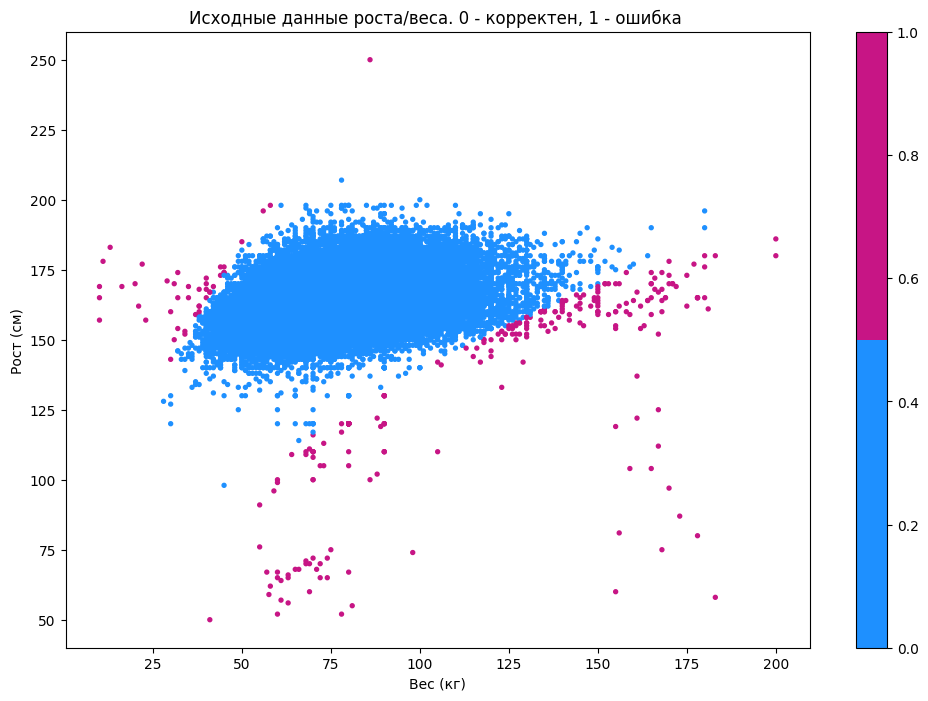

In [6]:
all_data_input = df_train
all_data_input['imt'] = all_data_input.weight / (np.square(all_data_input.height) / 10000)

plt.figure(figsize=(12, 8))
plt.scatter(all_data_input.weight, all_data_input.height, 
            c=((all_data_input.imt < 15) | (all_data_input.imt > 52)), s = 8, 
            cmap=ListedColormap(['dodgerblue','mediumvioletred']))
plt.colorbar()
plt.title('Исходные данные роста/веса. 0 - корректен, 1 - ошибка ')
plt.xlabel('Вес (кг)')
plt.ylabel('Рост (см)')

del all_data_input

In [7]:
def deviate_weight_height(Data, min_imt = 15, max_imt=52, coef_height = 24, coef_weight = 24, coef_age = 720):
        """Обработка некорректных данных в Data в столбцах 'weight', 'height'
        --------
        Некорректными считались данные пациентов, у которых Индекс Массы Тела -
        ИМТ < min_imt (дистрофия)или ИМТ > max_imt (сверх ожирение)
        --------
        Параметры
        --------
        * max_imt - максимальный индекс ИМТ, говорящий об ожирении
        * min_imt - минимальный индекс ИМТ, говорящий о дистрофии
        * coef_height - ИМТ для рассчета веса по росту
        * coef_weight - ИМТ для рассчета роста по весу
        * coef_age - допустимый отступ от реального возраста влево/вправо для взятия среднего по росту и весу
        """

        tmp_Data = Data.copy()
        # переводим рост в метры
        tmp_Data['height'] /= 100
        tmp_Data['imt'] = tmp_Data['weight'] / (tmp_Data['height'] * tmp_Data['height'])
        # выбор строк с некорректными данными
        dev_Data = tmp_Data[(tmp_Data['imt'] > max_imt) | (tmp_Data['imt'] < min_imt)]
        # выбор строк с корректными данными
        not_dev_Data = tmp_Data[(tmp_Data['imt'] < max_imt) | (tmp_Data['imt'] > min_imt)]

        new_weight = []
        new_height = []
        
        for imt, weight, height, age in zip(dev_Data['imt'],dev_Data['weight'], dev_Data['height'], dev_Data['age']):
            # если рост - нормальный, рассчитываем вес по росту
            if height > 1.20 and height < 2.30:
                weight = coef_height * height * height
            # если вес - нормальный, рассчитываем рост по весу
            elif weight > 30 and weight < 120:
                height = math.sqrt(weight / coef_weight)
            # иначе берем средний рост и вес по пациентам, возраст которых +- 2 года от возраста нашего пациента
            else:
                filter_Data = not_dev_Data[(not_dev_Data['age'] < age + coef_age) &
                                            (not_dev_Data['age'] > age - coef_age)]
                height = filter_Data['height'].mean()
                weight = filter_Data['weight'].mean()
                
            new_height.append(height)
            new_weight.append(weight)

        # изменяем некорректные значения на скорректированные
        mask = (tmp_Data['imt'] > max_imt) | (tmp_Data['imt'] < min_imt)
        
        tmp_Data.loc[mask, 'height'] = Series(new_height, index=dev_Data.index)
        tmp_Data.loc[mask, 'weight'] = Series(new_weight, index=dev_Data.index)
        # переводим рост в сантиметры
        tmp_Data['height'] *= 100
        # удаляем вставленный столбец с ИМТ
        tmp_Data = tmp_Data.drop('imt', axis=1)
        return tmp_Data

In [8]:
df_train = deviate_weight_height(df_train, max_imt=52, min_imt=15)

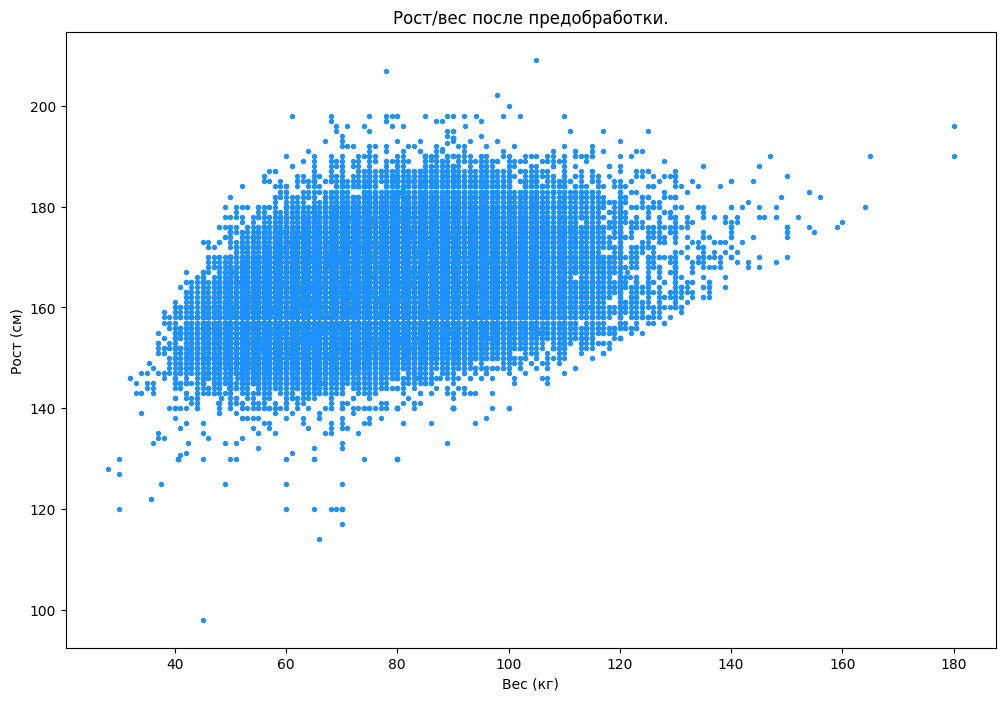

In [9]:
plt.figure(figsize=(12, 8))
all_data_normal_weight_height = df_train
plt.scatter(all_data_normal_weight_height.weight, all_data_normal_weight_height.height, s = 8, c = 'dodgerblue')
plt.title('Рост/вес после предобработки.')
plt.xlabel('Вес (кг)')
plt.ylabel('Рост (см)')
del all_data_normal_weight_height

Text(0, 0.5, 'Верхнее давление (мм. рт. ст.)')

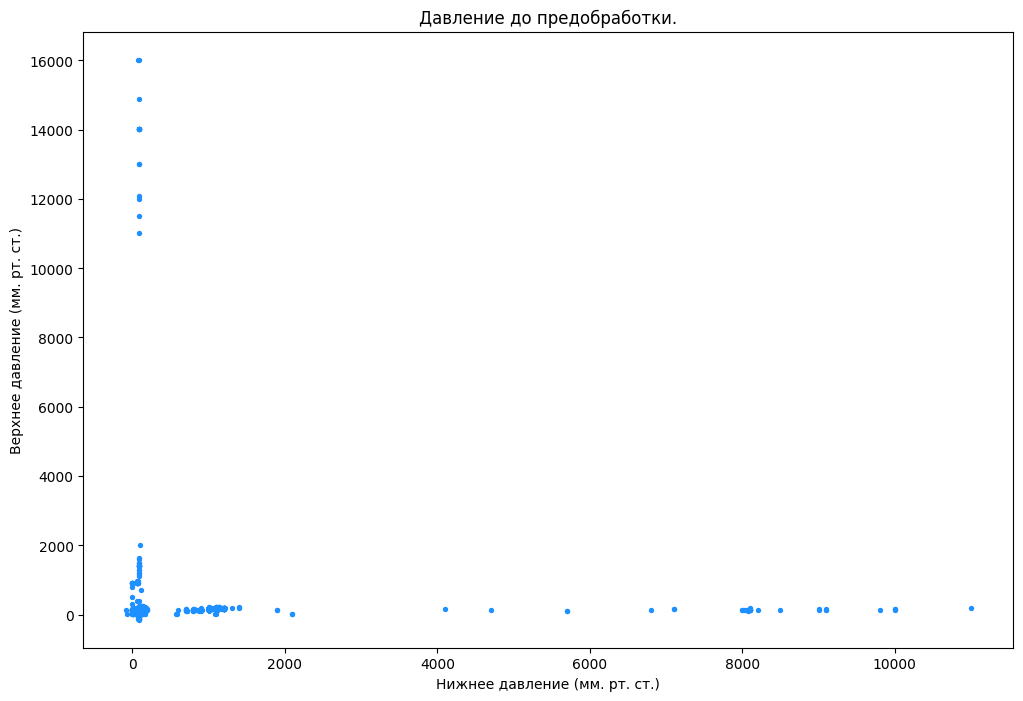

In [10]:
# По признакам ap_lo и ap_hi есть аномальные значения. Обработаем такие аномалии.
plt.figure(figsize=(12, 8))
plt.scatter(df_train.ap_lo, df_train.ap_hi, s = 8, c = 'dodgerblue')
plt.title('Давление до предобработки.')
plt.xlabel('Нижнее давление (мм. рт. ст.)')
plt.ylabel('Верхнее давление (мм. рт. ст.)')

In [11]:
def deviate_arterial_pressure(Data):
    """Обработка некорректных данных в Data в столбцах 'ap_hi', 'ap_lo'."""
    # работаем с копией, чтобы не менять исходный DataFrame (опционально)
    df_abs = Data.copy()
    
    # перевод отрицательных значений в положительные целые
    df_abs[['ap_hi', 'ap_lo']] = df_abs[['ap_hi', 'ap_lo']].abs().astype(int)

    # маска для некорректных значений
    mask = (df_abs['ap_hi'] > 300) | (df_abs['ap_hi'] < 30) | (df_abs['ap_lo'] > 200) | (df_abs['ap_lo'] < 10)
    
    # если нет некорректных данных – сразу возвращаем
    if not mask.any():
        return df_abs

    dev_data = df_abs.loc[mask, ['ap_hi', 'ap_lo']].copy()

    # средние нормальные давления (округляем до целых)
    ap_hi_mean = int(round(df_abs['ap_hi'].mean()))
    ap_lo_mean = int(round(df_abs['ap_lo'].mean()))

    new_ap_hi = []
    new_ap_lo = []
    
    for ap_hi, ap_lo in zip(dev_data['ap_hi'], dev_data['ap_lo']):
        err_flag = True

        # оба давления в норме
        if 30 < ap_hi < 300 and 10 < ap_lo < 200 and ap_hi > ap_lo:
            err_flag = False
            new_ap_hi.append(ap_hi)
            new_ap_lo.append(ap_lo)

        # верхнее норма, нижнее большое (160/1100 -> 160/110)
        elif 30 < ap_hi < 300 and ap_lo > 200:
            tmp_ap_hi, tmp_ap_lo = ap_hi, ap_lo
            f = True
            while len(str(ap_lo)) > 1:
                ap_lo //= 10
                if ap_lo < 200 and ap_hi > ap_lo:
                    f = False
                    err_flag = False
                    new_ap_lo.append(ap_lo)
                    new_ap_hi.append(ap_hi)
                    break
            if f:
                ap_hi, ap_lo = tmp_ap_hi, tmp_ap_lo

        # верхнее большое, нижнее норма (1600/90 -> 160/90)
        elif ap_hi > 300 and 10 < ap_lo < 200:
            tmp_ap_hi, tmp_ap_lo = ap_hi, ap_lo
            f = True
            while len(str(ap_hi)) > 1:
                ap_hi //= 10
                if ap_hi < 300 and ap_hi > ap_lo:
                    f = False
                    err_flag = False
                    new_ap_lo.append(ap_lo)
                    new_ap_hi.append(ap_hi)
                    break
            if f:
                ap_hi, ap_lo = tmp_ap_hi, tmp_ap_lo

        # верхнее большое, нижнее малое (906/0 -> 90/60)
        elif ap_hi > 300 and ap_lo < 10:
            mod = ap_hi % 10
            ap_hi //= 10
            ap_lo = int(str(mod) + str(ap_lo))
            if ap_hi < 300 and ap_lo > 10 and ap_hi > ap_lo:
                err_flag = False
                new_ap_lo.append(ap_lo)
                new_ap_hi.append(ap_hi)

        # верхнее малое, нижнее большое (9/770 -> 97/70)
        elif ap_hi < 30 and ap_lo > 200:
            len_ap_lo = len(str(ap_lo))
            first_digit = ap_lo // (10 ** (len_ap_lo - 1))
            ap_lo = ap_lo % (10 ** (len_ap_lo - 1))
            ap_hi = int(str(ap_hi) + str(first_digit))
            if ap_hi < 300 and ap_lo > 10 and ap_hi > ap_lo:
                err_flag = False
                new_ap_lo.append(ap_lo)
                new_ap_hi.append(ap_hi)

        # верхнее норма, нижнее малое (120/8 -> 120/80)
        elif 30 < ap_hi < 300 and ap_lo < 10 and ap_lo != 0:
            ap_lo *= 10
            if ap_lo > 10 and ap_hi > ap_lo:
                err_flag = False
                new_ap_lo.append(ap_lo)
                new_ap_hi.append(ap_hi)

        # верхнее малое, нижнее норма (8/60 -> 80/60)
        elif ap_hi < 30 and 10 < ap_lo < 200 and ap_hi != 0:
            ap_hi *= 10
            if ap_hi > 10 and ap_hi > ap_lo:
                err_flag = False
                new_ap_lo.append(ap_lo)
                new_ap_hi.append(ap_hi)

        # ошибка не исправлена
        if err_flag:
            # оба давления в норме, но переставлены местами
            if 30 < ap_hi < 300 and 10 < ap_lo < 200 and ap_hi < ap_lo:
                ap_hi, ap_lo = ap_lo, ap_hi
                new_ap_lo.append(ap_lo)
                new_ap_hi.append(ap_hi)
            # верхнее норма, нижнее отклонение – замена нижнего средним
            elif 30 < ap_hi < 300:
                subset = df_abs.loc[df_abs['ap_hi'] == ap_hi, 'ap_lo']
                ap_lo = int(round(subset.mean())) if not subset.empty else ap_lo_mean
                if ap_hi < ap_lo:
                    ap_hi, ap_lo = ap_lo, ap_hi
                new_ap_lo.append(ap_lo)
                new_ap_hi.append(ap_hi)
            # нижнее норма, верхнее отклонение – замена верхнего средним
            elif 10 < ap_lo < 200:
                subset = df_abs.loc[df_abs['ap_lo'] == ap_lo, 'ap_hi']
                ap_hi = int(round(subset.mean())) if not subset.empty else ap_hi_mean
                if ap_hi < ap_lo:
                    ap_hi, ap_lo = ap_lo, ap_hi
                new_ap_lo.append(ap_lo)
                new_ap_hi.append(ap_hi)
            # всё плохо – заменяем средними по выборке
            else:
                new_ap_lo.append(ap_lo_mean)
                new_ap_hi.append(ap_hi_mean)

    # Приведение к целым (на всякий случай)
    new_ap_hi = [int(round(x)) for x in new_ap_hi]
    new_ap_lo = [int(round(x)) for x in new_ap_lo]

    ap_lo_series = Series(new_ap_lo, index=dev_data.index)
    ap_hi_series = Series(new_ap_hi, index=dev_data.index)

    # Замена неверных значений исправленными по той же маске
    df_abs.loc[mask, 'ap_hi'] = ap_hi_series
    df_abs.loc[mask, 'ap_lo'] = ap_lo_series

    return df_abs

In [12]:
df_train = deviate_arterial_pressure(df_train)

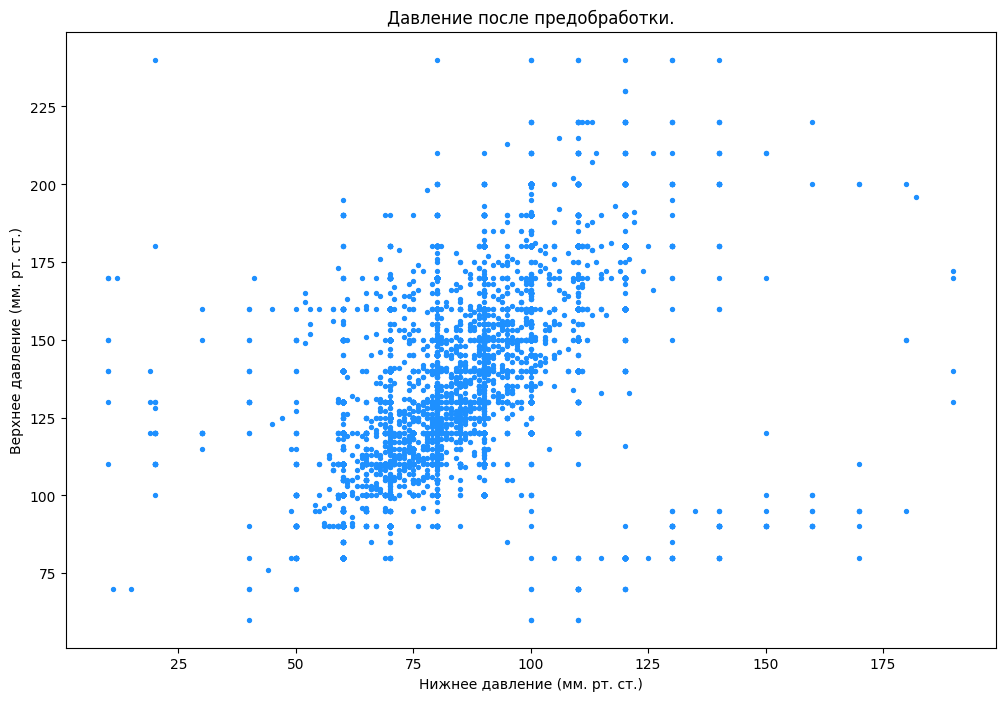

In [13]:
all_data_normal_pressure = df_train 

plt.figure(figsize=(12, 8))
plt.scatter(all_data_normal_pressure.ap_lo, all_data_normal_pressure.ap_hi, s = 8, c = 'dodgerblue')
plt.title('Давление после предобработки.')
plt.xlabel('Нижнее давление (мм. рт. ст.)')
plt.ylabel('Верхнее давление (мм. рт. ст.)')

del all_data_normal_pressure

In [14]:
# Выбираем все столбцы с типом float и преобразуем их в int
df_train_float_columns = df_train.select_dtypes(include=['float']).columns
df_train[df_train_float_columns] = df_train[df_train_float_columns].astype(int)

# Выбираем все столбцы с типом int64 и преобразуем их в int32
df_train_int64_columns = df_train.select_dtypes(include=['int64']).columns

# Преобразуем выбранные столбцы
df_train[df_train_int64_columns] = df_train[df_train_int64_columns].astype('int32')

# Проверяем результат
print(df_train.dtypes)

age            int32
gender         int32
height         int32
weight         int32
ap_hi          int32
ap_lo          int32
cholesterol    int32
gluc           int32
smoke          int32
alco           int32
active         int32
cardio         int32
dtype: object


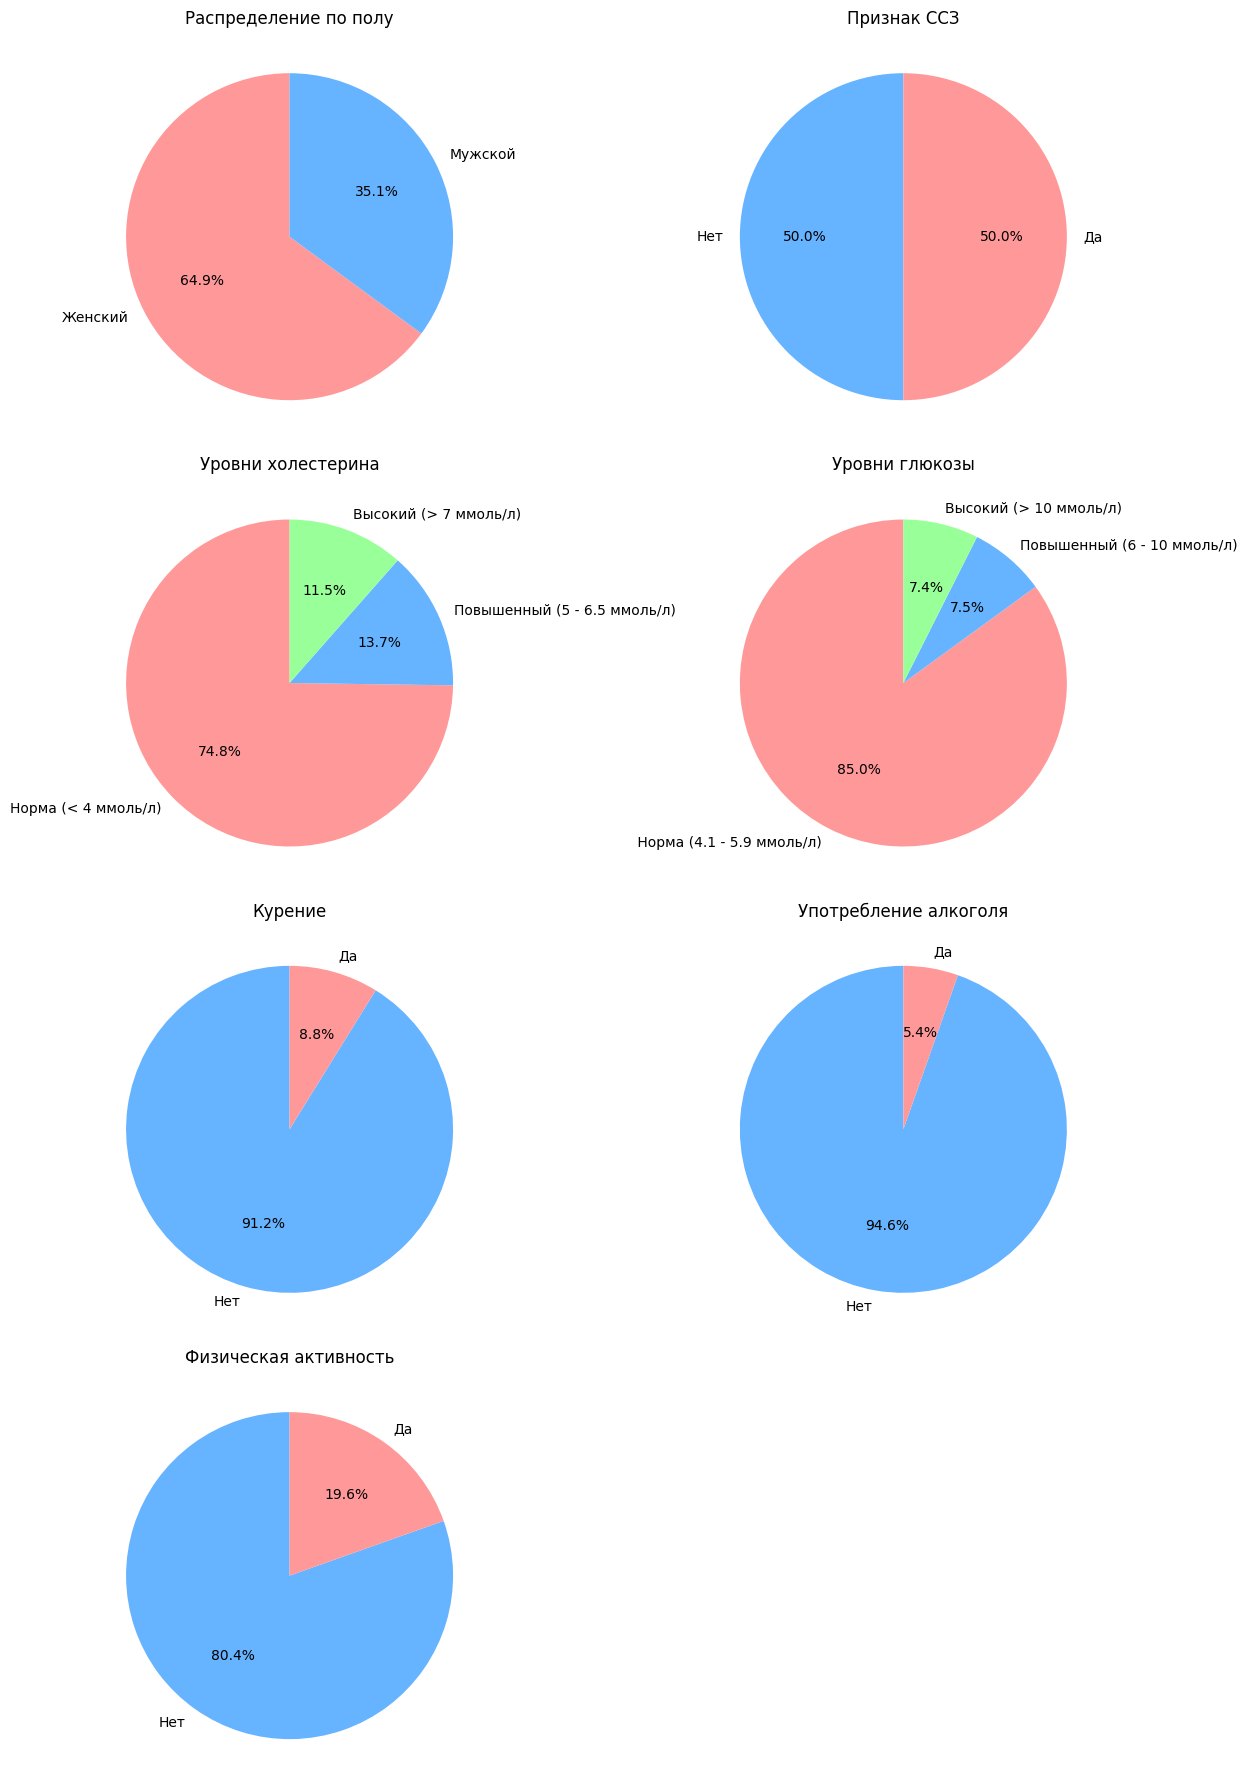

In [15]:
# Функция для создания круговой диаграммы
def plot_pie(column, labels, colors, title, ax):
    data = df_train[column].value_counts(normalize=True)
    ax.pie(data, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
    ax.set_title(title)

# Настройка цветов и меток для различных переменных
colors_binary = ['#66b3ff', '#ff9999']
labels_binary = ['Нет', 'Да']

fig, axs = plt.subplots(4, 2, figsize=(12, 18))  # Настройка сетки для вывода графиков

# Построение диаграмм для различных переменных
plot_pie('gender', ['Женский', 'Мужской'], ['#ff9999','#66b3ff'], 'Распределение по полу', axs[0, 0])
plot_pie('cardio', labels_binary, colors_binary, 'Признак ССЗ', axs[0, 1])
plot_pie('cholesterol', ['Норма (< 4 ммоль/л)', 'Повышенный (5 - 6.5 ммоль/л)', 'Высокий (> 7 ммоль/л)'], ['#ff9999', '#66b3ff', '#99ff99'], 'Уровни холестерина', axs[1, 0])
plot_pie('gluc', [' Норма (4.1 - 5.9 ммоль/л)', 'Повышенный (6 - 10 ммоль/л)', 'Высокий (> 10 ммоль/л)'], ['#ff9999', '#66b3ff', '#99ff99'], 'Уровни глюкозы', axs[1, 1])
plot_pie('smoke', labels_binary, colors_binary, 'Курение', axs[2, 0])
plot_pie('alco', labels_binary, colors_binary, 'Употребление алкоголя', axs[2, 1])
plot_pie('active', labels_binary, colors_binary, 'Физическая активность', axs[3, 0])

# Удаление лишних осей, если они есть
for i in range(4):
    for j in range(2):
        if not axs[i, j].has_data():
            fig.delaxes(axs[i][j])

plt.tight_layout()
plt.show()

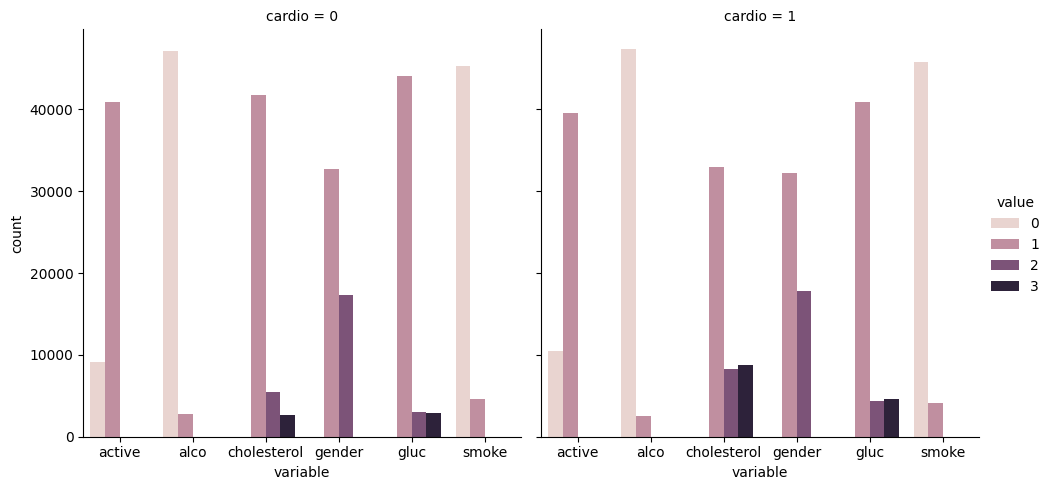

In [16]:
# Анализ уникальности значений cardio 
df_uniques = pd.melt(
    frame=df_train,
    value_vars=["gender", "cholesterol", "gluc", "smoke", "alco", "active"],
    id_vars=["cardio"]
)

# Группировка и подсчёт значений
df_uniques = (
    pd.DataFrame(df_uniques.groupby(["variable", "value", "cardio"])["value"].count())
    .sort_index(level=[0, 1])
    .rename(columns={"value": "count"})
    .reset_index()
)

# Визуализация данных
g = sns.catplot(
    x="variable",
    y="count",
    hue="value",
    col="cardio",
    data=df_uniques,
    kind="bar",
    height=5,  
    aspect=1 
)


plt.show()

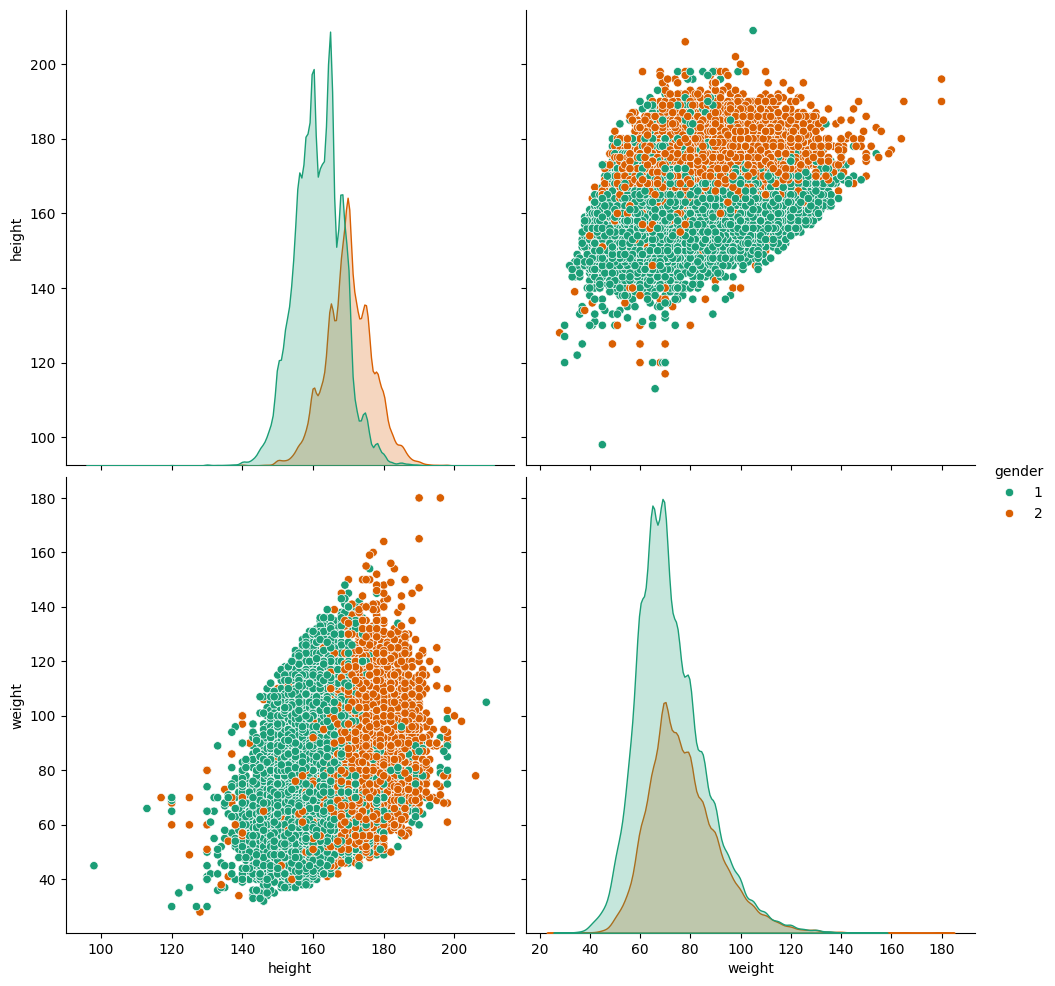

In [17]:
sns.pairplot(df_train[['height', 'weight', 'gender']], hue='gender', height=5, palette='Dark2');

In [18]:
# Вычислить средний рост для каждой группы гендера
average_heights = df_train.groupby('gender')['height'].mean()

print("Средний рост по группам гендера:")
print(average_heights)

# Определение, какой гендер выше
if average_heights[1] > average_heights[2]:
    print("Гендер '1' - мужчины, Гендер '2' - женщины")
    males = df_train[df_train['gender'] == 1]
    females = df_train[df_train['gender'] == 2]
else:
    print("Гендер '2' - мужчины, Гендер '1' - женщины")
    males = df_train[df_train['gender'] == 2]
    females = df_train[df_train['gender'] == 1]

# Подсчет количества мужчин и женщин
num_males = males.shape[0]
num_females = females.shape[0]

print(f"Количество мужчин: {num_males}, Количество женщин: {num_females}")

Средний рост по группам гендера:
gender
1    161.417465
2    170.002366
Name: height, dtype: float64
Гендер '2' - мужчины, Гендер '1' - женщины
Количество мужчин: 35082, Количество женщин: 64918


In [19]:
# Считаем количество людей, употребляющих алкоголь по полам
alcohol_consumption = df_train.groupby('gender')['alco'].sum()

# Вычисление общего количества мужчин и женщин в наборе данных
total_by_gender = df_train['gender'].value_counts()

# Вычисление процентного соотношения употребления алкоголя по полам
percentage_alcohol = (alcohol_consumption / total_by_gender) * 100

# Вывод результатов
print("Процент потребления алкоголя по полам:")
print(percentage_alcohol)

# Определяем, кто чаще употребляет алкоголь
if percentage_alcohol[1] > percentage_alcohol[2]:
    print("Женщины чаще сообщают о потреблении алкоголя.")
else:
    print("Мужчины чаще сообщают о потреблении алкоголя.")

Процент потребления алкоголя по полам:
gender
1     2.606365
2    10.609429
dtype: float64
Мужчины чаще сообщают о потреблении алкоголя.


In [20]:
# Считаем количество курильщиков по полам
smokers = df_train.groupby('gender')['smoke'].sum()

# Вычисление общего количества мужчин и женщин в наборе данных
total_by_gender = df_train['gender'].value_counts()

# Вычисление процентного соотношения курильщиков по полам
percentage_smokers = (smokers / total_by_gender) * 100

# Вывод результатов
print("Процент курильщиков по полам:")
print(percentage_smokers.round())

# Определение разницы в процентном соотношении курильщиков между мужчинами и женщинами
difference = abs(percentage_smokers[1] - percentage_smokers[2])

print(f"Разница между процентным соотношением курильщиков среди мужчин и женщин: {round(difference)}%")


Процент курильщиков по полам:
gender
1     2.0
2    22.0
dtype: float64
Разница между процентным соотношением курильщиков среди мужчин и женщин: 20%


Можно сделать вывод, что 1 закодированы 'женщины' (так в среднем их рост и вес чуть ниже, чем у мужчин), а 2 - 'мужчины'.

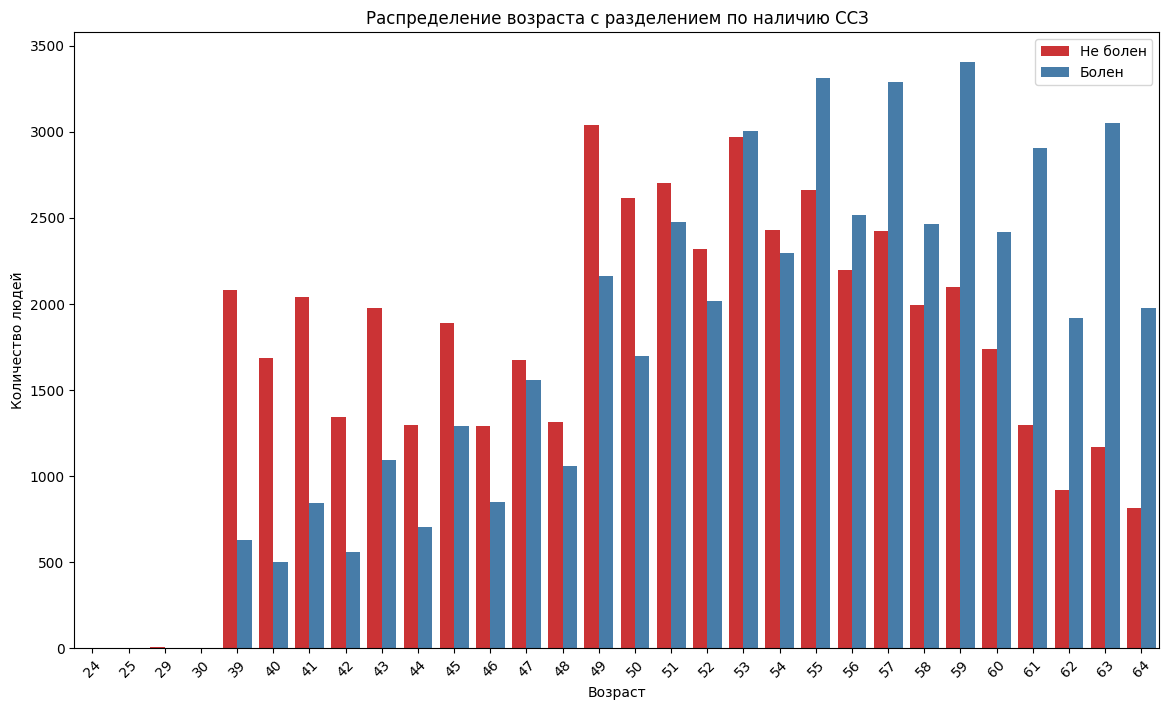

In [21]:
# Анализ распределения возраста по наличию ССЗ

plt.figure(figsize=(14, 8))  # Установка размера фигуры
sns.countplot(x='age', hue='cardio', data=df_train, palette='Set1')
plt.title('Распределение возраста с разделением по наличию ССЗ')
plt.xlabel('Возраст')
plt.ylabel('Количество людей')
plt.xticks(rotation=45)  # Поворот подписей оси X для лучшей видимости
plt.legend(labels=['Не болен', 'Болен'])
plt.show()


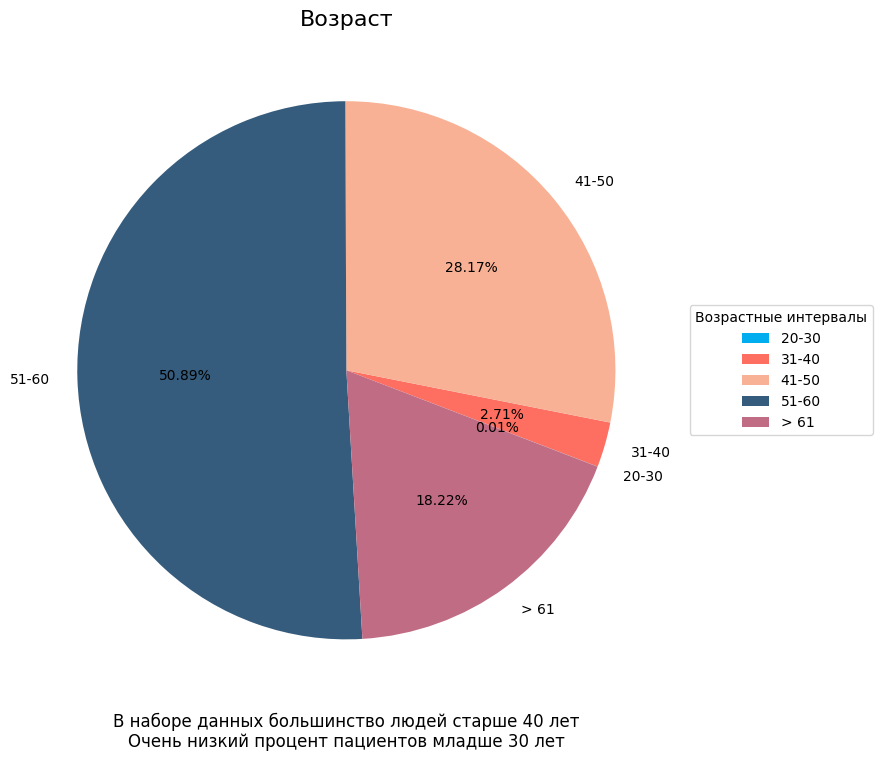

In [22]:
# Подсчитываем количество по возрастным группам
# Создаем категорию возрастных интервалов
bins = [20, 30, 40, 50, 60, 70]
labels = ['20-30', '31-40', '41-50', '51-60', '> 61']
df_train['age_group'] = pd.cut(df_train['age'], bins=bins, labels=labels, right=False)

age_group_counts = df_train['age_group'].value_counts().sort_index()
colors_age = ['#00AEEF', '#FF6F61', '#F8B195', '#355C7D', '#C06C84', '#F67280']

fig, ax = plt.subplots(figsize=(12, 8)) 

wedges, texts, autotexts = ax.pie(age_group_counts, labels=age_group_counts.index, colors=colors_age, autopct='%1.2f%%', startangle=339)
ax.set_title('Возраст', fontsize=16)

# Добавляем пояснительный текст
ax.text(0, -1.4, "В наборе данных большинство людей старше 40 лет\nОчень низкий процент пациентов младше 30 лет", fontsize=12, ha='center')

# Добавляем легенду
ax.legend(wedges, labels, title="Возрастные интервалы", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

plt.tight_layout(rect=[0, 0, 0.9, 0.96])
plt.show()
df_train.drop('age_group', axis=1, inplace=True)

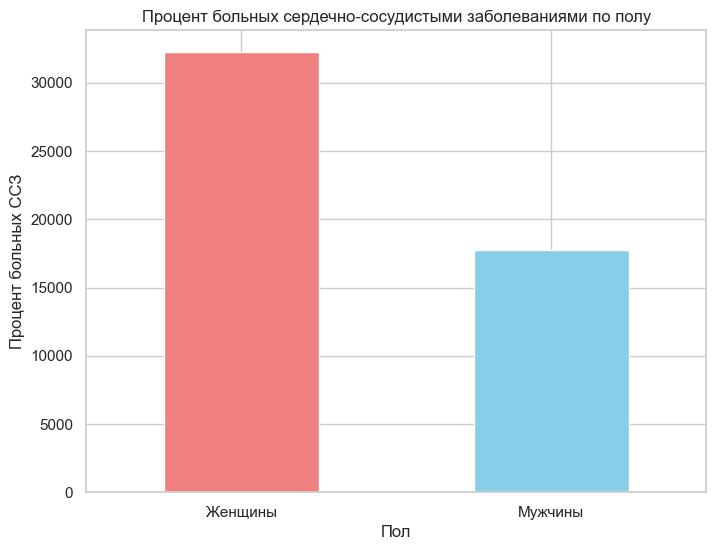

In [23]:
# Установка стиля
sns.set_theme(style="whitegrid")

# Подготовка данных
# Считаем количество больных и здоровых по полам
cardio_counts = df_train.groupby(['gender', 'cardio']).size().unstack(fill_value=0)


# Создание столбчатой диаграммы
fig, ax = plt.subplots(figsize=(8, 6))
cardio_counts[1].plot(kind='bar', color=['lightcoral', 'skyblue'], ax=ax)  # 1 - болеет
ax.set_ylabel('Процент больных ССЗ')
ax.set_xlabel('Пол')
ax.set_title('Процент больных сердечно-сосудистыми заболеваниями по полу')
ax.set_xticklabels(['Женщины', 'Мужчины'], rotation=0)


# Показать график
plt.show()


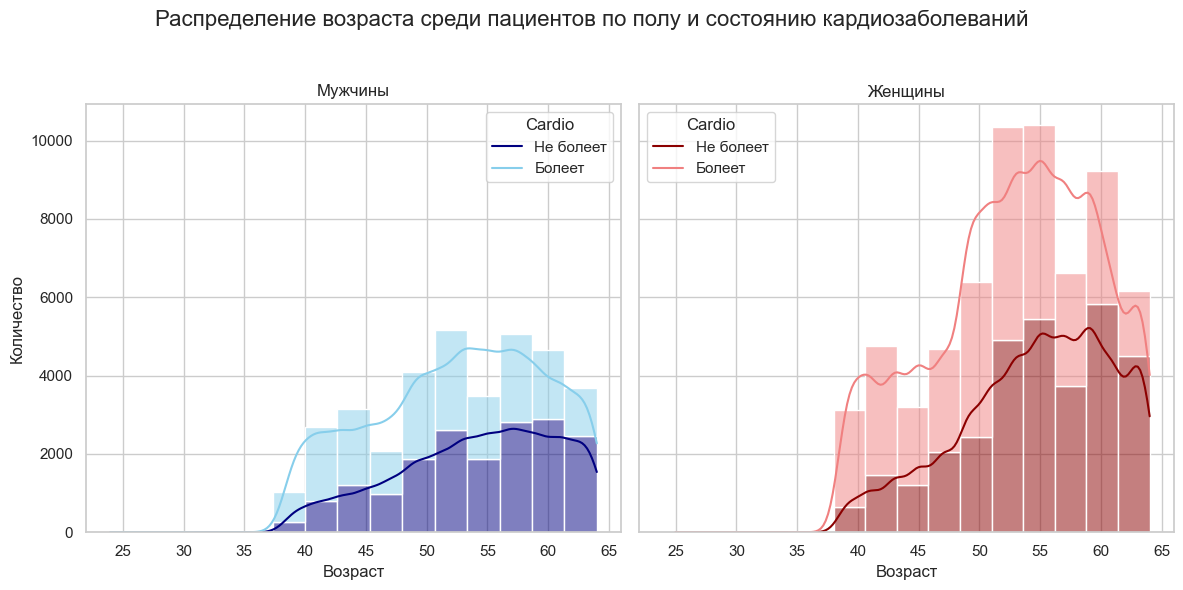

In [24]:
sns.set_theme(style="whitegrid")

fig, (ax_male, ax_female) = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)

# Мужчины
sns.histplot(data=df_train[df_train['gender'] == 2], x='age', hue='cardio', kde=True,
             palette=['skyblue', 'navy'], ax=ax_male, bins=15, multiple="stack")
ax_male.set_title('Мужчины')
ax_male.set_xlabel('Возраст')
ax_male.set_ylabel('Количество')
# Легенда создаётся автоматически, можно перенастроить её местоположение при необходимости
ax_male.legend(title='Cardio', labels=['Не болеет', 'Болеет'], loc='upper right')

# Женщины
sns.histplot(data=df_train[df_train['gender'] == 1], x='age', hue='cardio', kde=True,
             palette=['lightcoral', 'darkred'], ax=ax_female, bins=15, multiple="stack")
ax_female.set_title('Женщины')
ax_female.set_xlabel('Возраст')
ax_female.set_ylabel('')
ax_female.legend(title='Cardio', labels=['Не болеет', 'Болеет'], loc='upper left')

# Общий заголовок
fig.suptitle('Распределение возраста среди пациентов по полу и состоянию кардиозаболеваний', fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.95])  # rect оставляет место для общего заголовка
plt.show()

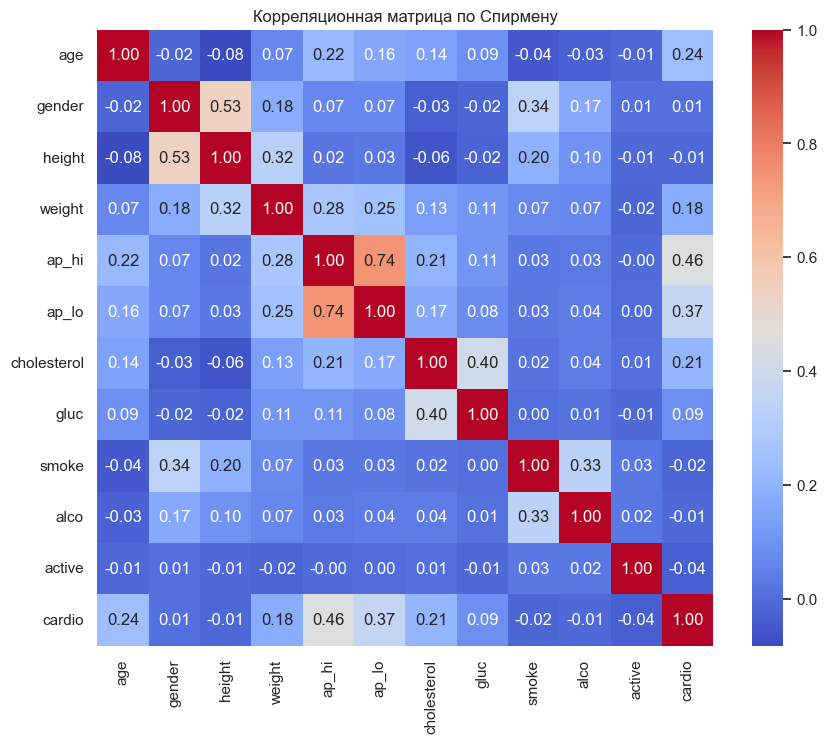

In [25]:
# Расчет корреляционной матрицы Спирмена
spearman_corr = df_train.corr(method='spearman')

# Визуализация корреляционной матрицы с использованием Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap='coolwarm', cbar=True, square=True)
plt.title('Корреляционная матрица по Спирмену')
plt.show()


     Variable 1   Variable 2  Cramer's V
0   cholesterol         gluc    0.389376
6          gluc  cholesterol    0.389376
20        smoke       gender    0.336943
14       gender        smoke    0.336943
27         alco        smoke    0.334834
21        smoke         alco    0.334834
5   cholesterol       cardio    0.219516
36       cardio  cholesterol    0.219516
26         alco       gender    0.168700
15       gender         alco    0.168700
37       cardio         gluc    0.088802
11         gluc       cardio    0.088802
3   cholesterol         alco    0.042916
24         alco  cholesterol    0.042916
35       active       cardio    0.034844
41       cardio       active    0.034844
12       gender  cholesterol    0.034003
1   cholesterol       gender    0.034003
22        smoke       active    0.029212
33       active        smoke    0.029212
2   cholesterol        smoke    0.028017
18        smoke  cholesterol    0.028017
25         alco         gluc    0.025678
9          gluc 

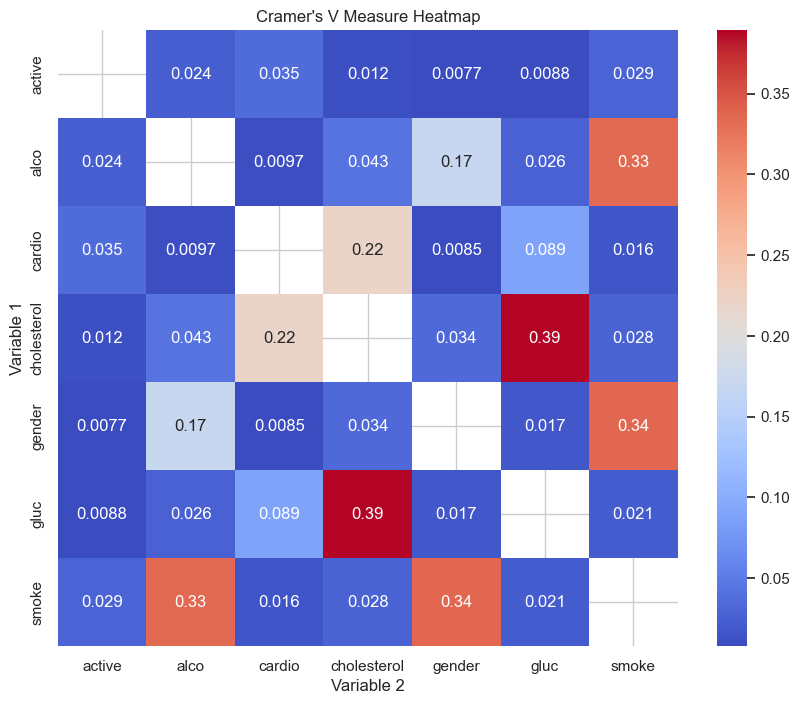

In [26]:
# Определение числовых и категориальных признаков
numeric_columns = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']
categorical_columns = ['cholesterol', 'gluc', 'gender', 'smoke', 'alco', 'active', 'cardio']

# Функция для расчета V-меры Крамера
def cramers_v(confusion_matrix):
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()  # Общее количество элементов в матрице
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k - 1)*(r - 1)) / (n - 1))
    rcorr = r - ((r - 1)**2) / (n - 1)
    kcorr = k - ((k - 1)**2) / (n - 1)
    return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))

# Функция для создания матрицы частот и расчета V-меры Крамера
def calculate_cramers_v(df, col1, col2):
    confusion_matrix = pd.crosstab(df[col1], df[col2])
    return cramers_v(confusion_matrix)

# Расчет V-меры Крамера для всех пар признаков
results = []
for col1 in categorical_columns:
    for col2 in categorical_columns:
        if col1 != col2:
            v = calculate_cramers_v(df_train, col1, col2)
            results.append((col1, col2, v))

# Преобразование результатов в DataFrame
results_df = pd.DataFrame(results, columns=['Variable 1', 'Variable 2', 'Cramer\'s V'])
results_df = results_df.sort_values(by='Cramer\'s V', ascending=False)

# Вывод результатов
print(results_df)

# Создание сводной таблицы для тепловой карты
pivot_table = results_df.pivot_table(index='Variable 1', columns='Variable 2', values='Cramer\'s V')

# Визуализация V-меры Крамера
plt.figure(figsize=(10, 8))
heatmap = sns.heatmap(pivot_table, annot=True, cmap='coolwarm')
plt.title('Cramer\'s V Measure Heatmap')
plt.show()


In [27]:
anova_results = []
for cat_col in categorical_columns:
    for num_col in numeric_columns:
        f_val, p_val = stats.f_oneway(
            *[df_train[df_train[cat_col] == cat][num_col] for cat in df_train[cat_col].unique()]
        )
        anova_results.append((cat_col, num_col, f_val, p_val))

anova_df = pd.DataFrame(anova_results, columns=['Categorical Variable', 'Numerical Variable', 'F-value', 'P-value'])
anova_df = anova_df.sort_values(by='P-value')

# Вывод результатов ANOVA
print(anova_df)


   Categorical Variable Numerical Variable       F-value        P-value
0           cholesterol                age   1292.849648   0.000000e+00
2           cholesterol             weight   1025.353050   0.000000e+00
3           cholesterol              ap_hi   1985.280409   0.000000e+00
4           cholesterol              ap_lo   1311.464250   0.000000e+00
12               gender             weight   2885.796063   0.000000e+00
11               gender             height  36895.504018   0.000000e+00
30               cardio                age   6244.028965   0.000000e+00
16                smoke             height   3907.461264   0.000000e+00
33               cardio              ap_hi  22643.683900   0.000000e+00
34               cardio              ap_lo  13208.871659   0.000000e+00
32               cardio             weight   3390.431220   0.000000e+00
7                  gluc             weight    722.109307  4.315212e-312
8                  gluc              ap_hi    510.839786  1.8655

In [28]:
# Дисперсия для числовых признаков
numeric_variance = df_train.var()

# Вывод результатов
print(numeric_variance)

age             45.839881
gender           0.227748
height          62.277873
weight         197.020281
ap_hi          291.985968
ap_lo           99.927139
cholesterol      0.462294
gluc             0.325520
smoke            0.080479
alco             0.051209
active           0.157385
cardio           0.250003
dtype: float64


In [29]:
# Медиана для числовых признаков
numeric_median = df_train.median()

# Мода для числовых признаков
numeric_mode = df_train.mode().iloc[0]

# Вывод результатов
print("Медиана:\n", numeric_median)
print("\nМода:\n", numeric_mode)

Медиана:
 age             53.0
gender           1.0
height         165.0
weight          72.0
ap_hi          120.0
ap_lo           80.0
cholesterol      1.0
gluc             1.0
smoke            0.0
alco             0.0
active           1.0
cardio           0.5
dtype: float64

Мода:
 age             55.0
gender           1.0
height         165.0
weight          65.0
ap_hi          120.0
ap_lo           80.0
cholesterol      1.0
gluc             1.0
smoke            0.0
alco             0.0
active           1.0
cardio           0.0
Name: 0, dtype: float64


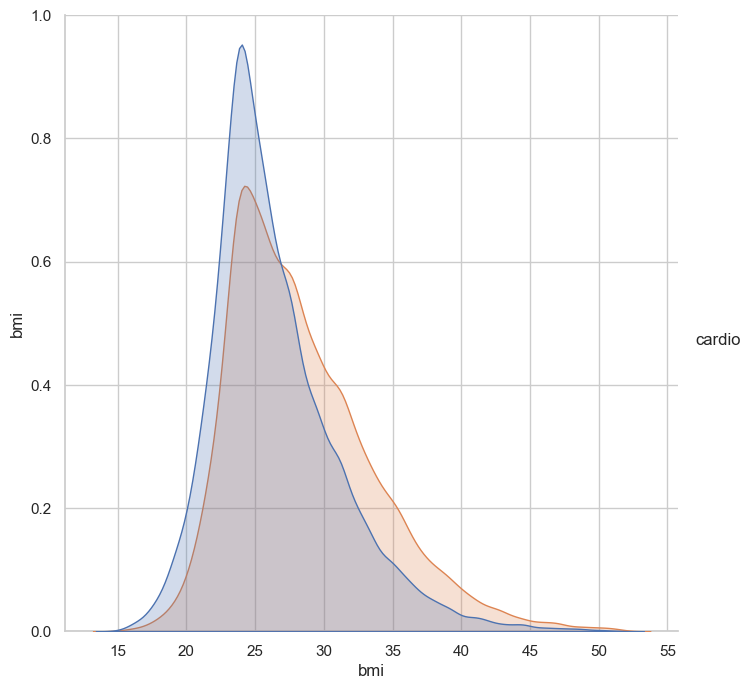

In [30]:
df_train['bmi'] = df_train['weight'] / (df_train['height'] * df_train['height'] / 10000)

sns.pairplot(df_train[['bmi', 'cardio']],  hue='cardio', height=7);

Из графика видно что индекс массы тела практически не дает разделения выборки по таргету cardio.

Расчитаем среднее артериальное давление.

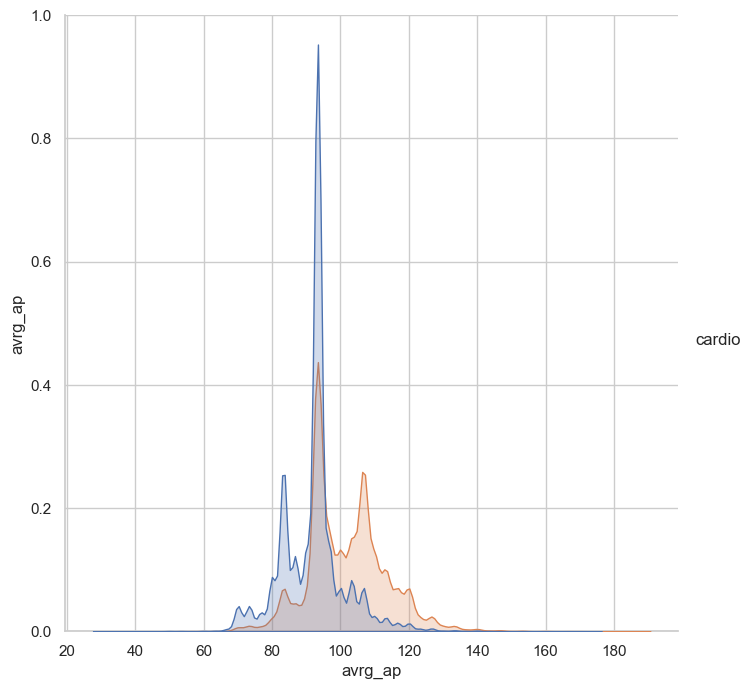

In [31]:
df_train['avrg_ap'] = np.round((2 * df_train['ap_lo'] + df_train['ap_hi']) / 3, 1)

_ = sns.pairplot(df_train[['avrg_ap', 'cardio']], hue='cardio', height=7)

Из графика видно, что новый признак достаточно разделяет выборки по таргету.

Подсчитаем как наличие холестерина, сахара с учетом артериального давления и возраста может повлиять на риск возникновения ССЗ.

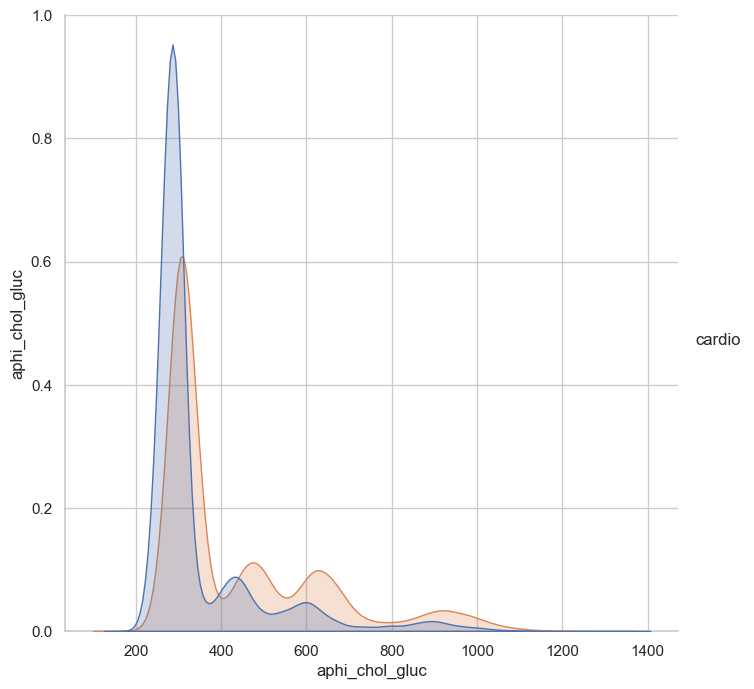

In [32]:
df_train['aphi_chol_gluc'] = (df_train['avrg_ap'] + df_train['age']) * (df_train['cholesterol'] + df_train['gluc'])

_ = sns.pairplot(df_train[['aphi_chol_gluc', 'cardio']],  hue='cardio', height=7);

Расчитаем риск ССЗ с учетом возраста, среднего артериального давления и показатедя aphi_chol_gluc.

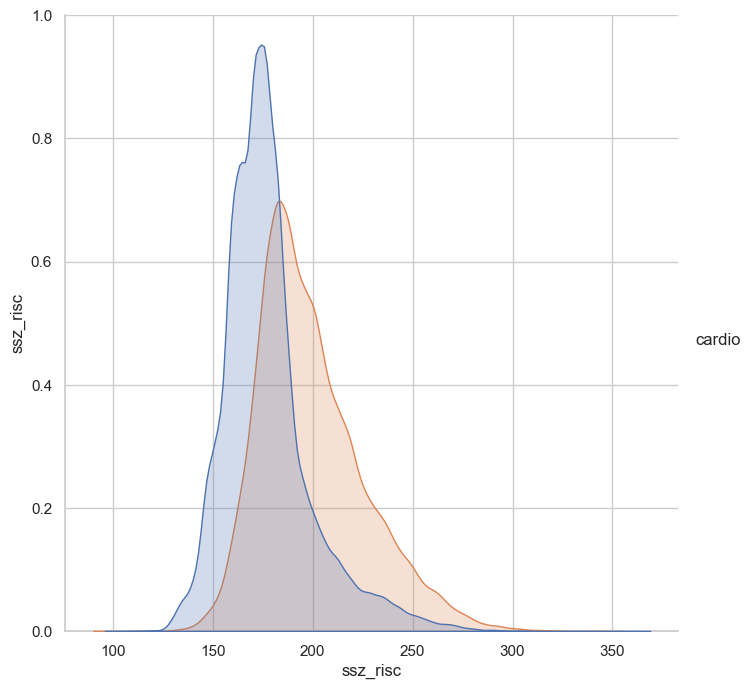

In [33]:
df_train['ssz_risc'] = (df_train['age'] + df_train['avrg_ap'] + df_train['aphi_chol_gluc'] // 10)

_ = sns.pairplot(df_train[['ssz_risc', 'cardio']], hue='cardio', height=7);

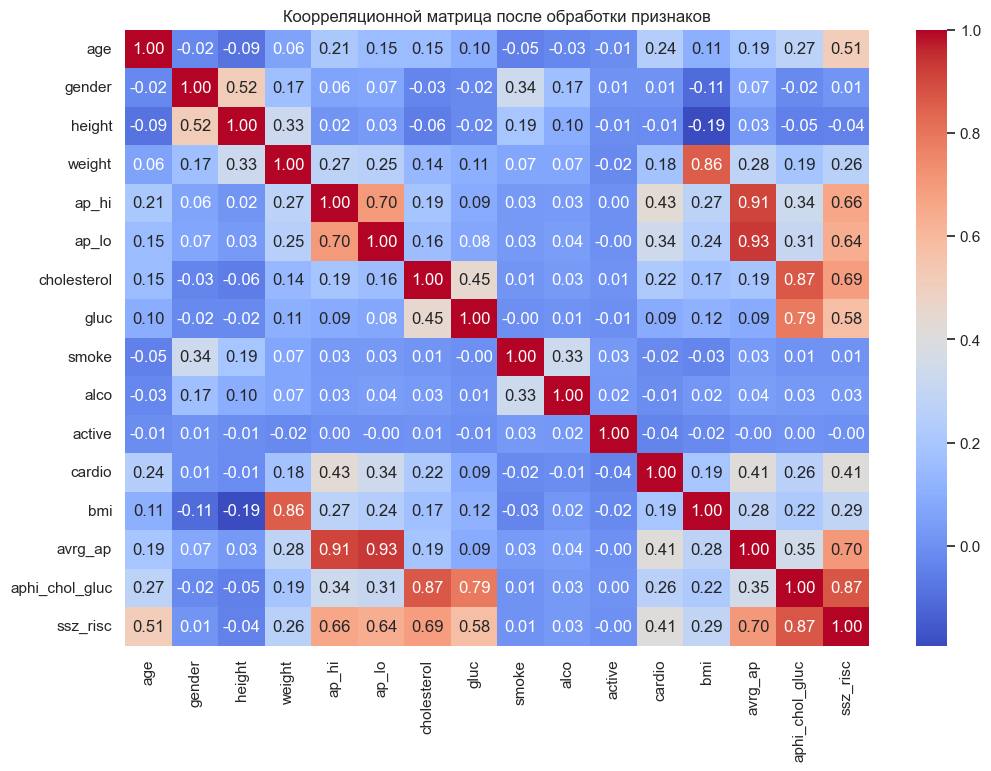

In [34]:
# Построение корреляционной матрицы
correlation_matrix = df_train.corr()

# Визуализация корреляционной матрицы
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Кoорреляционной матрица после обработки признаков")
plt.show()

# xgboost

In [35]:
def objective(trial):
    # Разделение данных
    X = df_train.drop('cardio', axis=1)
    y = df_train['cardio']
    X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.3, random_state=42)

    # Параметры модели
    param = {
        'verbosity': 0,
        'objective': 'binary:logistic',
        'tree_method': 'hist',
        'random_state': 0,
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.2, 1.0),
        'subsample': trial.suggest_float('subsample', 0.2, 1.0),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'n_estimators': trial.suggest_int('n_estimators', 10, 1000),
        'max_depth': trial.suggest_int('max_depth', 2, 9),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 300),
    }

    clf = xgb.XGBClassifier(**param)

    # Подготовка аргументов для fit (без early stopping)
    fit_kwargs = {
        'eval_set': [(X_valid, y_valid)],
        'verbose': False,
    }

    start_time = time.time()
    clf.fit(X_train, y_train, **fit_kwargs)
    training_time = time.time() - start_time

    # Предсказания и метрики
    preds = clf.predict(X_valid)
    proba_preds = clf.predict_proba(X_valid)[:, 1]

    logloss = log_loss(y_valid, proba_preds)
    trial.set_user_attr('Accuracy', accuracy_score(y_valid, preds))
    trial.set_user_attr('Log Loss', logloss)
    trial.set_user_attr('ROC AUC', roc_auc_score(y_valid, proba_preds))
    trial.set_user_attr('F1 Score', f1_score(y_valid, preds))
    trial.set_user_attr('Precision', precision_score(y_valid, preds))
    trial.set_user_attr('Recall', recall_score(y_valid, preds))
    trial.set_user_attr('Training Time (s)', training_time)

    return logloss

# Создание объекта исследования и оптимизация
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=100)

# Получение лучшего триала
best_trial = study.best_trial

# Вывод лучших параметров
print("Best trial:")
print(f"Value (Log Loss): {best_trial.value}")
print("Parameters:")
for key, value in best_trial.params.items():
    print(f"{key}: {value}")

# Также можно вывести дополнительные метрики, сохраненные в атрибутах пользователя
print("\nAdditional Metrics:")
for key, value in best_trial.user_attrs.items():
    print(f"{key}: {value}")


[I 2026-03-12 00:27:46,101] A new study created in memory with name: no-name-27dd6a58-f518-49ff-bd76-6b2078147e93
[I 2026-03-12 00:27:46,784] Trial 0 finished with value: 0.5542685850278161 and parameters: {'colsample_bytree': 0.36396959525561495, 'subsample': 0.46235120141156427, 'learning_rate': 0.01987387484773238, 'n_estimators': 96, 'max_depth': 9, 'min_child_weight': 189}. Best is trial 0 with value: 0.5542685850278161.
[I 2026-03-12 00:27:47,379] Trial 1 finished with value: 0.5385170397106426 and parameters: {'colsample_bytree': 0.29358160267817723, 'subsample': 0.7516562204711734, 'learning_rate': 0.0663538324765607, 'n_estimators': 89, 'max_depth': 5, 'min_child_weight': 292}. Best is trial 1 with value: 0.5385170397106426.
[I 2026-03-12 00:27:50,442] Trial 2 finished with value: 0.5356193673452452 and parameters: {'colsample_bytree': 0.4261244079277189, 'subsample': 0.9380816731694659, 'learning_rate': 0.05661379699523472, 'n_estimators': 767, 'max_depth': 3, 'min_child_weig

Best trial:
Value (Log Loss): 0.5351553949032472
Parameters:
colsample_bytree: 0.5083263749448966
subsample: 0.921587829932821
learning_rate: 0.018097883430877273
n_estimators: 686
max_depth: 5
min_child_weight: 98

Additional Metrics:
Accuracy: 0.7408666666666667
Log Loss: 0.5351553949032472
ROC AUC: 0.8063949902506443
F1 Score: 0.7294682628062361
Precision: 0.7630870040043684
Recall: 0.6986867542163856
Training Time (s): 2.6667420864105225


# xgboost_graph

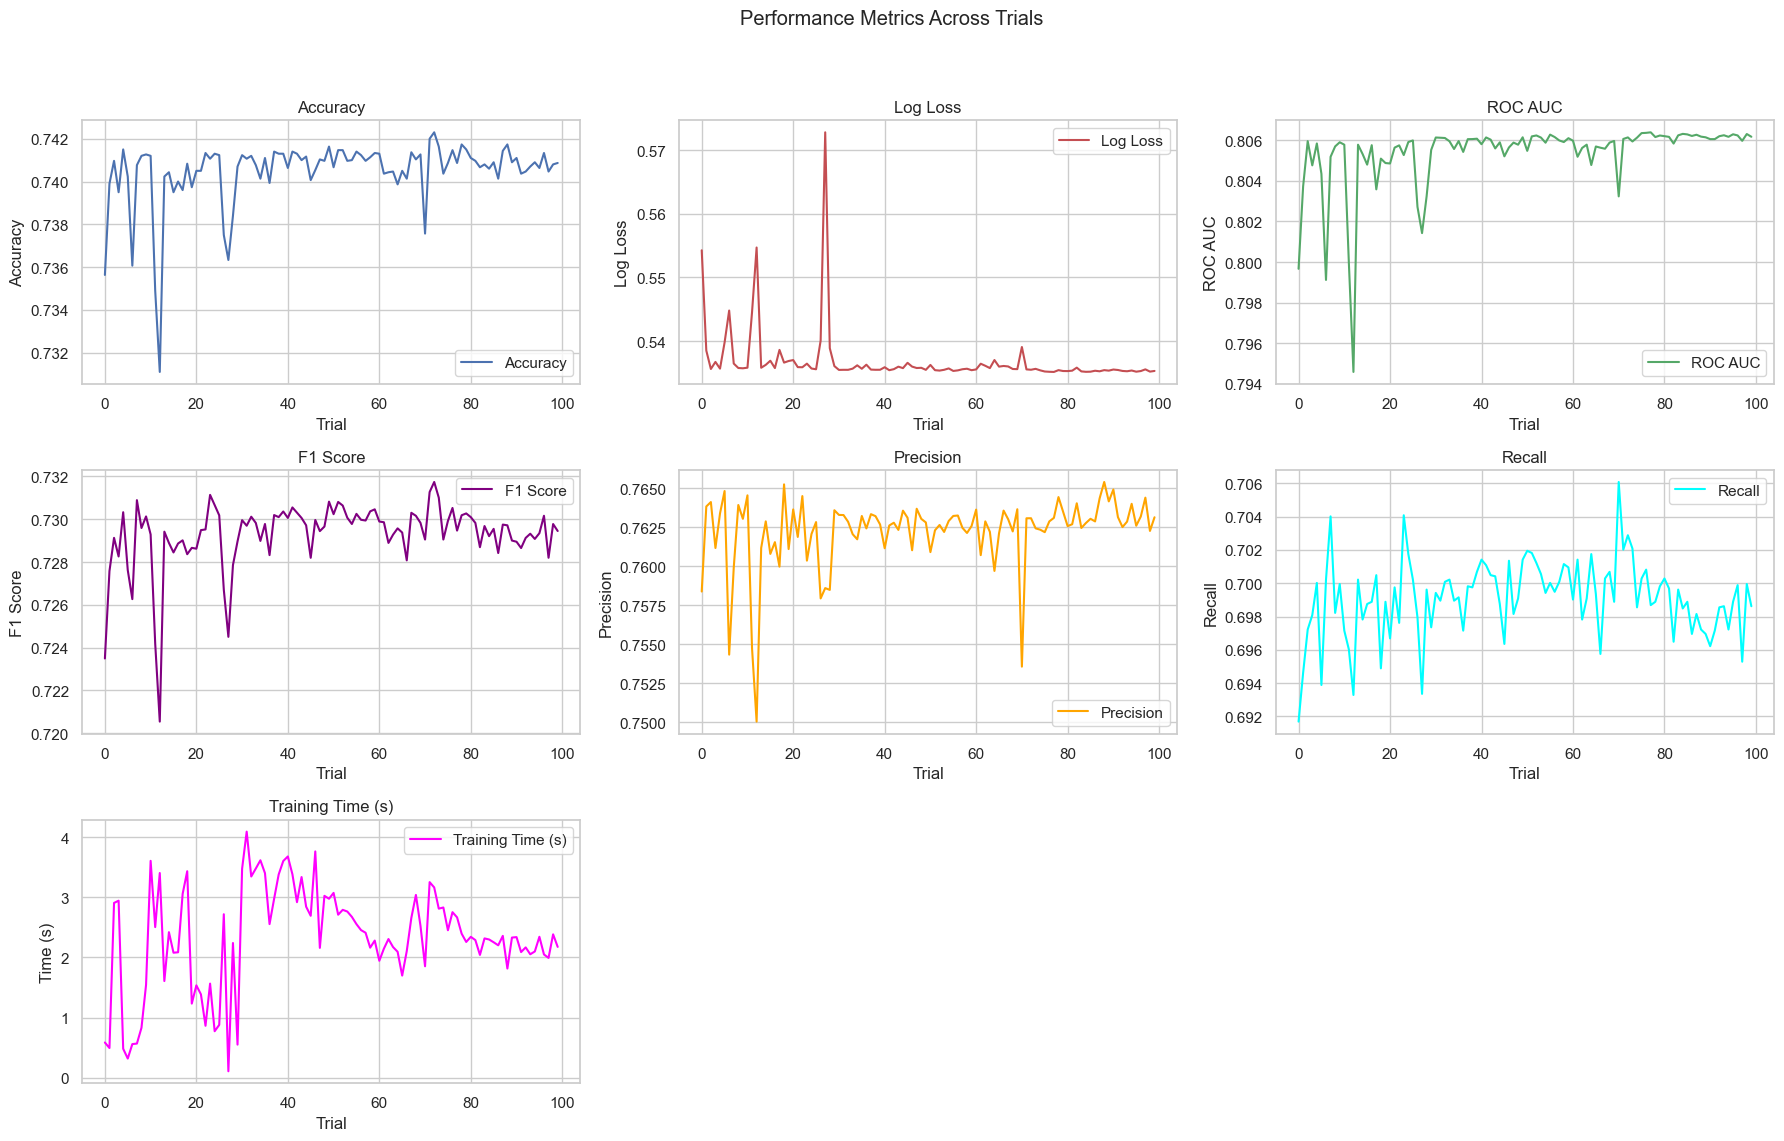

In [36]:
# Извлечение данных из истории триалов
accuracies = [trial.user_attrs['Accuracy'] for trial in study.trials]
log_losses = [trial.values[0] for trial in study.trials]
roc_aucs = [trial.user_attrs['ROC AUC'] for trial in study.trials]
f1_scores = [trial.user_attrs['F1 Score'] for trial in study.trials]
precisions = [trial.user_attrs['Precision'] for trial in study.trials]
recalls = [trial.user_attrs['Recall'] for trial in study.trials]
training_times = [trial.user_attrs['Training Time (s)'] for trial in study.trials]

# Построение графиков
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
fig.suptitle('Performance Metrics Across Trials')

# Accuracy
axes[0, 0].plot(accuracies, label='Accuracy', color='b')
axes[0, 0].set_title('Accuracy')
axes[0, 0].set_xlabel('Trial')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()

# Log Loss
axes[0, 1].plot(log_losses, label='Log Loss', color='r')
axes[0, 1].set_title('Log Loss')
axes[0, 1].set_xlabel('Trial')
axes[0, 1].set_ylabel('Log Loss')
axes[0, 1].legend()

# ROC AUC
axes[0, 2].plot(roc_aucs, label='ROC AUC', color='g')
axes[0, 2].set_title('ROC AUC')
axes[0, 2].set_xlabel('Trial')
axes[0, 2].set_ylabel('ROC AUC')
axes[0, 2].legend()

# F1 Score
axes[1, 0].plot(f1_scores, label='F1 Score', color='purple')
axes[1, 0].set_title('F1 Score')
axes[1, 0].set_xlabel('Trial')
axes[1, 0].set_ylabel('F1 Score')
axes[1, 0].legend()

# Precision
axes[1, 1].plot(precisions, label='Precision', color='orange')
axes[1, 1].set_title('Precision')
axes[1, 1].set_xlabel('Trial')
axes[1, 1].set_ylabel('Precision')
axes[1, 1].legend()

# Recall
axes[1, 2].plot(recalls, label='Recall', color='cyan')
axes[1, 2].set_title('Recall')
axes[1, 2].set_xlabel('Trial')
axes[1, 2].set_ylabel('Recall')
axes[1, 2].legend()

# Training Time
axes[2, 0].plot(training_times, label='Training Time (s)', color='magenta')
axes[2, 0].set_title('Training Time (s)')
axes[2, 0].set_xlabel('Trial')
axes[2, 0].set_ylabel('Time (s)')
axes[2, 0].legend()

# Очистка неиспользуемых субплотов
axes[2, 1].axis('off')
axes[2, 2].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


# xgboost_learn

[0]	train-logloss:0.68315	test-logloss:0.68310


c:\Users\pentryyy\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\callback.py:385: UserWarning: [00:32:00] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "n_estimators" } are not used.

  self.starting_round = model.num_boosted_rounds()


[50]	train-logloss:0.54568	test-logloss:0.54607
[100]	train-logloss:0.53548	test-logloss:0.53731
[150]	train-logloss:0.53312	test-logloss:0.53586
[200]	train-logloss:0.53172	test-logloss:0.53545
[250]	train-logloss:0.53077	test-logloss:0.53532
[255]	train-logloss:0.53069	test-logloss:0.53532


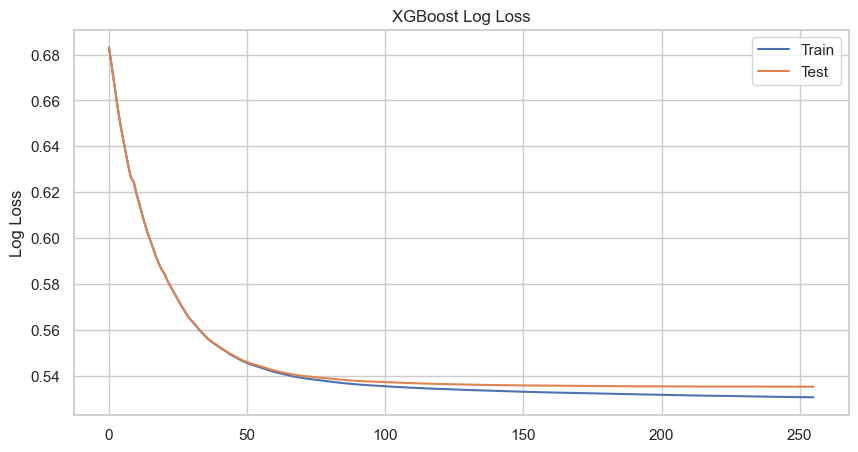

In [37]:
# Категориальные и числовые столбцы
categorical_columns = ['cholesterol', 'gluc', 'gender', 'smoke', 'alco', 'active']
numerical_columns = ['age', 'height', 'weight', 'ap_hi', 'ap_lo', 'bmi', 'avrg_ap', 'aphi_chol_gluc', 'ssz_risc']

# Разделение данных на признаки и целевую переменную
X = df_train.drop('cardio', axis=1)
y = df_train['cardio']

# Подготовка данных
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Создание DMatrix
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

# Параметры XGBoost
params = {
    'random_state': 0,
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'n_estimators': 784,
    'max_depth': 5,
    'learning_rate': 0.03763684704283537,
    'tree_method':'hist',
    'colsample_bytree': 0.5737561467653175,
    'subsample': 0.9256409353682482,
    'min_child_weight': 106,
}

# Словарь для хранения результатов
evals_result = {}

# Обучение модели
evals = [(dtrain, 'train'), (dtest, 'test')]
num_rounds = 1000
bst = xgb.train(params, dtrain, num_rounds, evals=evals, evals_result=evals_result, verbose_eval=50, early_stopping_rounds=10)

# Извлечение значений log loss
epochs = len(evals_result['train']['logloss'])
x_axis = range(0, epochs)

# Создание графика
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x_axis, evals_result['train']['logloss'], label='Train')
ax.plot(x_axis, evals_result['test']['logloss'], label='Test')
ax.legend()

plt.ylabel('Log Loss')
plt.title('XGBoost Log Loss')
plt.show()

# lightgbm

In [38]:
def objective(trial):
    # Разделение данных
    X = df_train.drop('cardio', axis=1)
    y = df_train['cardio']
    X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.3, random_state=42)

    # Параметры для тюнинга
    param = {
        'objective': 'binary',
        'metric': 'binary_logloss',
        'device': 'gpu',  # Использование GPU
        'boosting_type': 'gbdt',
        'random_state': 0,
        'lambda_l1': trial.suggest_float('lambda_l1', 1e-8, 10.0, log=True),
        'lambda_l2': trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 31, 256),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.4, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.4, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'n_estimators': trial.suggest_int('n_estimators', 10, 1000),
        'verbose': -1
    }

    # Создание модели
    clf = lgb.LGBMClassifier(**param)

    # Callback для ранней остановки
    early_stopping = lgb.early_stopping(stopping_rounds=10, verbose=True)

    # Обучение модели
    start_time = time.time()
    clf.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], eval_metric='logloss', callbacks=[early_stopping])
    training_time = time.time() - start_time

    # Вычисление метрик
    preds = clf.predict(X_valid)
    proba_preds = clf.predict_proba(X_valid)[:, 1]
    logloss = log_loss(y_valid, proba_preds)
    accuracy = accuracy_score(y_valid, preds)
    roc_auc = roc_auc_score(y_valid, proba_preds)
    f1 = f1_score(y_valid, preds)
    precision = precision_score(y_valid, preds)
    recall = recall_score(y_valid, preds)

    # Запись результатов
    trial.set_user_attr('Accuracy', accuracy)
    trial.set_user_attr('Log Loss', logloss)
    trial.set_user_attr('ROC AUC', roc_auc)
    trial.set_user_attr('F1 Score', f1)
    trial.set_user_attr('Precision', precision)
    trial.set_user_attr('Recall', recall)
    trial.set_user_attr('Training Time (s)', training_time)

    return logloss

# Создание и оптимизация исследования
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=100)

# Вывод лучших параметров и дополнительных метрик
best_trial = study.best_trial
print("Лучший триал:")
print(f"Значение (Log Loss): {best_trial.value}")
print("Параметры:")
for key, value in best_trial.params.items():
    print(f"{key}: {value}")

print("\nДополнительные метрики:")
for key, value in best_trial.user_attrs.items():
    print(f"{key}: {value}")


[I 2026-03-12 00:32:01,296] A new study created in memory with name: no-name-96896296-6777-4afa-9b0c-593475e9b0b1


Training until validation scores don't improve for 10 rounds


[I 2026-03-12 00:32:05,580] Trial 0 finished with value: 0.5381875722188858 and parameters: {'lambda_l1': 0.023247022848482384, 'lambda_l2': 1.508727812637482e-08, 'num_leaves': 132, 'feature_fraction': 0.956915564909493, 'bagging_fraction': 0.7440844326219298, 'bagging_freq': 5, 'min_child_samples': 14, 'learning_rate': 0.08472513536221696, 'n_estimators': 337}. Best is trial 0 with value: 0.5381875722188858.


Early stopping, best iteration is:
[40]	valid_0's binary_logloss: 0.538188
Training until validation scores don't improve for 10 rounds


[I 2026-03-12 00:32:08,751] Trial 1 finished with value: 0.5386348521849212 and parameters: {'lambda_l1': 1.2816595930335167e-06, 'lambda_l2': 0.08154757476230817, 'num_leaves': 151, 'feature_fraction': 0.9879767651694475, 'bagging_fraction': 0.4905471303494779, 'bagging_freq': 3, 'min_child_samples': 83, 'learning_rate': 0.06661359301933857, 'n_estimators': 451}. Best is trial 0 with value: 0.5381875722188858.


...

Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[207]	valid_0's binary_logloss: 0.535546


[I 2026-03-12 00:40:57,071] Trial 98 finished with value: 0.5355456527931102 and parameters: {'lambda_l1': 1.80137528453765e-07, 'lambda_l2': 1.776274439026182e-06, 'num_leaves': 35, 'feature_fraction': 0.6828152668904967, 'bagging_fraction': 0.7988362862912612, 'bagging_freq': 4, 'min_child_samples': 46, 'learning_rate': 0.024390102034311707, 'n_estimators': 746}. Best is trial 84 with value: 0.535148462168952.


Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[163]	valid_0's binary_logloss: 0.536635


[I 2026-03-12 00:41:05,198] Trial 99 finished with value: 0.536634716066635 and parameters: {'lambda_l1': 0.0006597427526257898, 'lambda_l2': 0.00018216994660931669, 'num_leaves': 136, 'feature_fraction': 0.5845941128966333, 'bagging_fraction': 0.8182435890940013, 'bagging_freq': 5, 'min_child_samples': 24, 'learning_rate': 0.02701681825365744, 'n_estimators': 884}. Best is trial 84 with value: 0.535148462168952.


Лучший триал:
Значение (Log Loss): 0.535148462168952
Параметры:
lambda_l1: 2.016986976698804e-05
lambda_l2: 3.7589102236654833e-06
num_leaves: 36
feature_fraction: 0.5637915852355334
bagging_fraction: 0.8246241925092406
bagging_freq: 6
min_child_samples: 51
learning_rate: 0.0253611931753487
n_estimators: 880

Дополнительные метрики:
Accuracy: 0.7408666666666667
Log Loss: 0.535148462168952
ROC AUC: 0.806348856917106
F1 Score: 0.7295247373182103
Precision: 0.7629721272105378
Recall: 0.6988867408839411
Training Time (s): 4.327268123626709


# lightgbm_graph

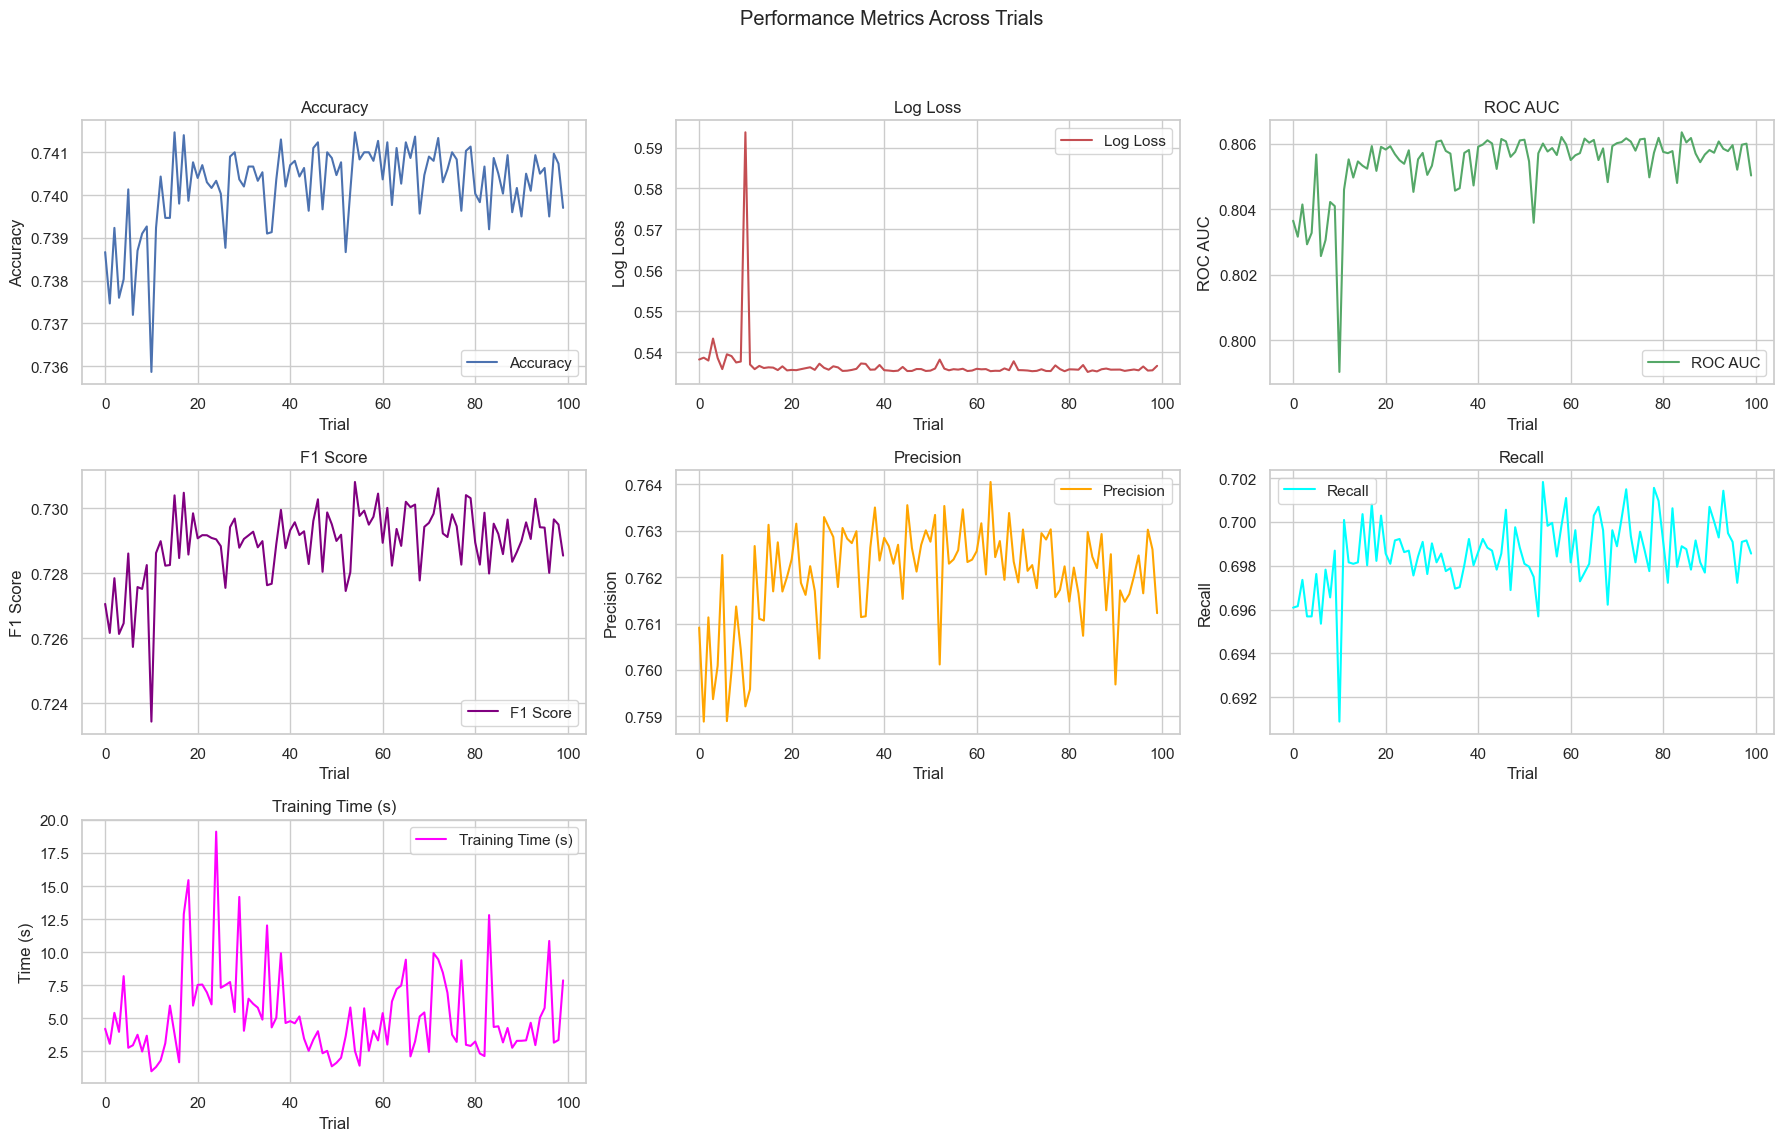

In [39]:
# Извлечение данных из истории триалов
accuracies = [trial.user_attrs['Accuracy'] for trial in study.trials]
log_losses = [trial.values[0] for trial in study.trials]
roc_aucs = [trial.user_attrs['ROC AUC'] for trial in study.trials]
f1_scores = [trial.user_attrs['F1 Score'] for trial in study.trials]
precisions = [trial.user_attrs['Precision'] for trial in study.trials]
recalls = [trial.user_attrs['Recall'] for trial in study.trials]
training_times = [trial.user_attrs['Training Time (s)'] for trial in study.trials]

# Построение графиков
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
fig.suptitle('Performance Metrics Across Trials')

# Accuracy
axes[0, 0].plot(accuracies, label='Accuracy', color='b')
axes[0, 0].set_title('Accuracy')
axes[0, 0].set_xlabel('Trial')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()

# Log Loss
axes[0, 1].plot(log_losses, label='Log Loss', color='r')
axes[0, 1].set_title('Log Loss')
axes[0, 1].set_xlabel('Trial')
axes[0, 1].set_ylabel('Log Loss')
axes[0, 1].legend()

# ROC AUC
axes[0, 2].plot(roc_aucs, label='ROC AUC', color='g')
axes[0, 2].set_title('ROC AUC')
axes[0, 2].set_xlabel('Trial')
axes[0, 2].set_ylabel('ROC AUC')
axes[0, 2].legend()

# F1 Score
axes[1, 0].plot(f1_scores, label='F1 Score', color='purple')
axes[1, 0].set_title('F1 Score')
axes[1, 0].set_xlabel('Trial')
axes[1, 0].set_ylabel('F1 Score')
axes[1, 0].legend()

# Precision
axes[1, 1].plot(precisions, label='Precision', color='orange')
axes[1, 1].set_title('Precision')
axes[1, 1].set_xlabel('Trial')
axes[1, 1].set_ylabel('Precision')
axes[1, 1].legend()

# Recall
axes[1, 2].plot(recalls, label='Recall', color='cyan')
axes[1, 2].set_title('Recall')
axes[1, 2].set_xlabel('Trial')
axes[1, 2].set_ylabel('Recall')
axes[1, 2].legend()

# Training Time
axes[2, 0].plot(training_times, label='Training Time (s)', color='magenta')
axes[2, 0].set_title('Training Time (s)')
axes[2, 0].set_xlabel('Trial')
axes[2, 0].set_ylabel('Time (s)')
axes[2, 0].legend()

# Очистка неиспользуемых субплотов
axes[2, 1].axis('off')
axes[2, 2].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


# lightgbm_learn

Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[331]	train's binary_logloss: 0.52581	valid's binary_logloss: 0.535345


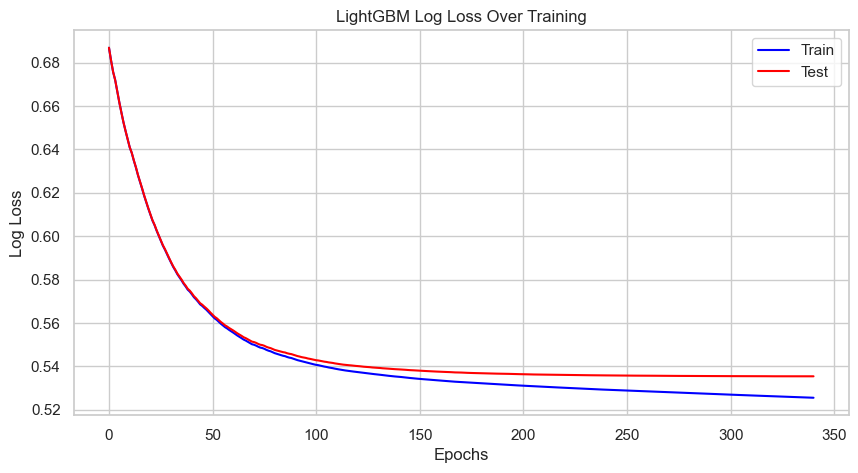

In [40]:
# Предполагается, что df_train уже загружен и содержит необходимые данные
X = df_train.drop('cardio', axis=1)
y = df_train['cardio']

# Разделение данных на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Создание датасетов для LightGBM
train_data = lgb.Dataset(X_train, label=y_train)
valid_data = lgb.Dataset(X_test, label=y_test)

# Параметры модели LightGBM
params = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'random_state': 0,
    'learning_rate': 0.023124521753140295,
    'n_estimators': 929,
    'num_leaves': 31,
    'min_child_samples': 70,
    'feature_fraction': 0.49233144168351883,
    'bagging_fraction': 0.9159371930878285,
    'bagging_freq': 1,
    'lambda_l1': 1.3213887596871343,
    'lambda_l2': 8.585146879940105e-05,
    'verbose': -1 
}

# Словарь для хранения результатов валидации
evals_result = {}

# Callback для записи истории оценки
record_eval_callback = lgb.record_evaluation(evals_result)

# Обучение модели с правильным использованием параметров
model = lgb.train(params, train_data, num_boost_round=1000, 
                  valid_sets=[train_data, valid_data], valid_names=['train', 'valid'],
                  callbacks=[record_eval_callback, lgb.early_stopping(10)])

# Извлечение значений log loss
train_logloss = evals_result['train']['binary_logloss']
valid_logloss = evals_result['valid']['binary_logloss']
epochs = len(train_logloss)
x_axis = range(0, epochs)

# Создание графика
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x_axis, train_logloss, label='Train', color='blue')
ax.plot(x_axis, valid_logloss, label='Test', color='red')
ax.legend()

plt.ylabel('Log Loss')
plt.xlabel('Epochs')
plt.title('LightGBM Log Loss Over Training')
plt.show()


# catboost

In [41]:
def objective(trial):
    # Разделение данных
    X = df_train.drop('cardio', axis=1)
    y = df_train['cardio']
    X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.3, random_state=42)

    # Параметры для тюнинга
    param = {
        'iterations': trial.suggest_int('iterations', 100, 1000),
        'depth': trial.suggest_int('depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'random_strength': trial.suggest_int('random_strength', 1, 10),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'border_count': trial.suggest_int('border_count', 5, 255),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-1, 10),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 0.1, 10),
        'loss_function': 'Logloss',
        'eval_metric': 'Logloss',
        'task_type': 'GPU',  # Если доступен GPU
        'random_state':0,
        'verbose': False
    }

    # Создание модели
    clf = cb.CatBoostClassifier(**param)

    # Обучение модели
    start_time = time.time()
    clf.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], early_stopping_rounds=10)
    training_time = time.time() - start_time

    # Вычисление метрик
    preds = clf.predict(X_valid)
    proba_preds = clf.predict_proba(X_valid)[:, 1]
    logloss = log_loss(y_valid, proba_preds)
    accuracy = accuracy_score(y_valid, preds)
    roc_auc = roc_auc_score(y_valid, proba_preds)
    f1 = f1_score(y_valid, preds)
    precision = precision_score(y_valid, preds)
    recall = recall_score(y_valid, preds)

    # Запись результатов
    trial.set_user_attr('Accuracy', accuracy)
    trial.set_user_attr('Log Loss', logloss)
    trial.set_user_attr('ROC AUC', roc_auc)
    trial.set_user_attr('F1 Score', f1)
    trial.set_user_attr('Precision', precision)
    trial.set_user_attr('Recall', recall)
    trial.set_user_attr('Training Time (s)', training_time)

    return logloss

# Создание и оптимизация исследования
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=100)

# Вывод лучших параметров и дополнительных метрик
best_trial = study.best_trial
print("Лучший триал:")
print(f"Значение (Log Loss): {best_trial.value}")
print("Параметры:")
for key, value in best_trial.params.items():
    print(f"{key}: {value}")

print("\nДополнительные метрики:")
for key, value in best_trial.user_attrs.items():
    print(f"{key}: {value}")


[I 2026-03-12 00:41:08,409] A new study created in memory with name: no-name-89d95dc2-0a3f-4c0b-8138-04a51af41775
[I 2026-03-12 00:41:09,873] Trial 0 finished with value: 0.9302906020366142 and parameters: {'iterations': 922, 'depth': 5, 'learning_rate': 0.204864760051019, 'random_strength': 6, 'bagging_temperature': 0.20635218211576478, 'border_count': 250, 'l2_leaf_reg': 4.410720706073292, 'scale_pos_weight': 8.905296715616641}. Best is trial 0 with value: 0.9302906020366142.
[I 2026-03-12 00:41:10,936] Trial 1 finished with value: 0.5381130960556267 and parameters: {'iterations': 936, 'depth': 6, 'learning_rate': 0.1344821264570171, 'random_strength': 1, 'bagging_temperature': 0.9099484852569275, 'border_count': 179, 'l2_leaf_reg': 2.6614041561746085, 'scale_pos_weight': 1.181797302936942}. Best is trial 1 with value: 0.5381130960556267.
[I 2026-03-12 00:41:12,111] Trial 2 finished with value: 0.5444912376918014 and parameters: {'iterations': 279, 'depth': 4, 'learning_rate': 0.1951

Лучший триал:
Значение (Log Loss): 0.5356863287600739
Параметры:
iterations: 386
depth: 5
learning_rate: 0.06885561767412261
random_strength: 1
bagging_temperature: 0.2931595580809897
border_count: 229
l2_leaf_reg: 4.983902757815249
scale_pos_weight: 1.0305981603834815

Дополнительные метрики:
Accuracy: 0.7401666666666666
Log Loss: 0.5356863287600739
ROC AUC: 0.8056841369141516
F1 Score: 0.7311790874918095
Precision: 0.7574306944841384
Recall: 0.7066862209186054
Training Time (s): 1.9490232467651367


# catboost_graph

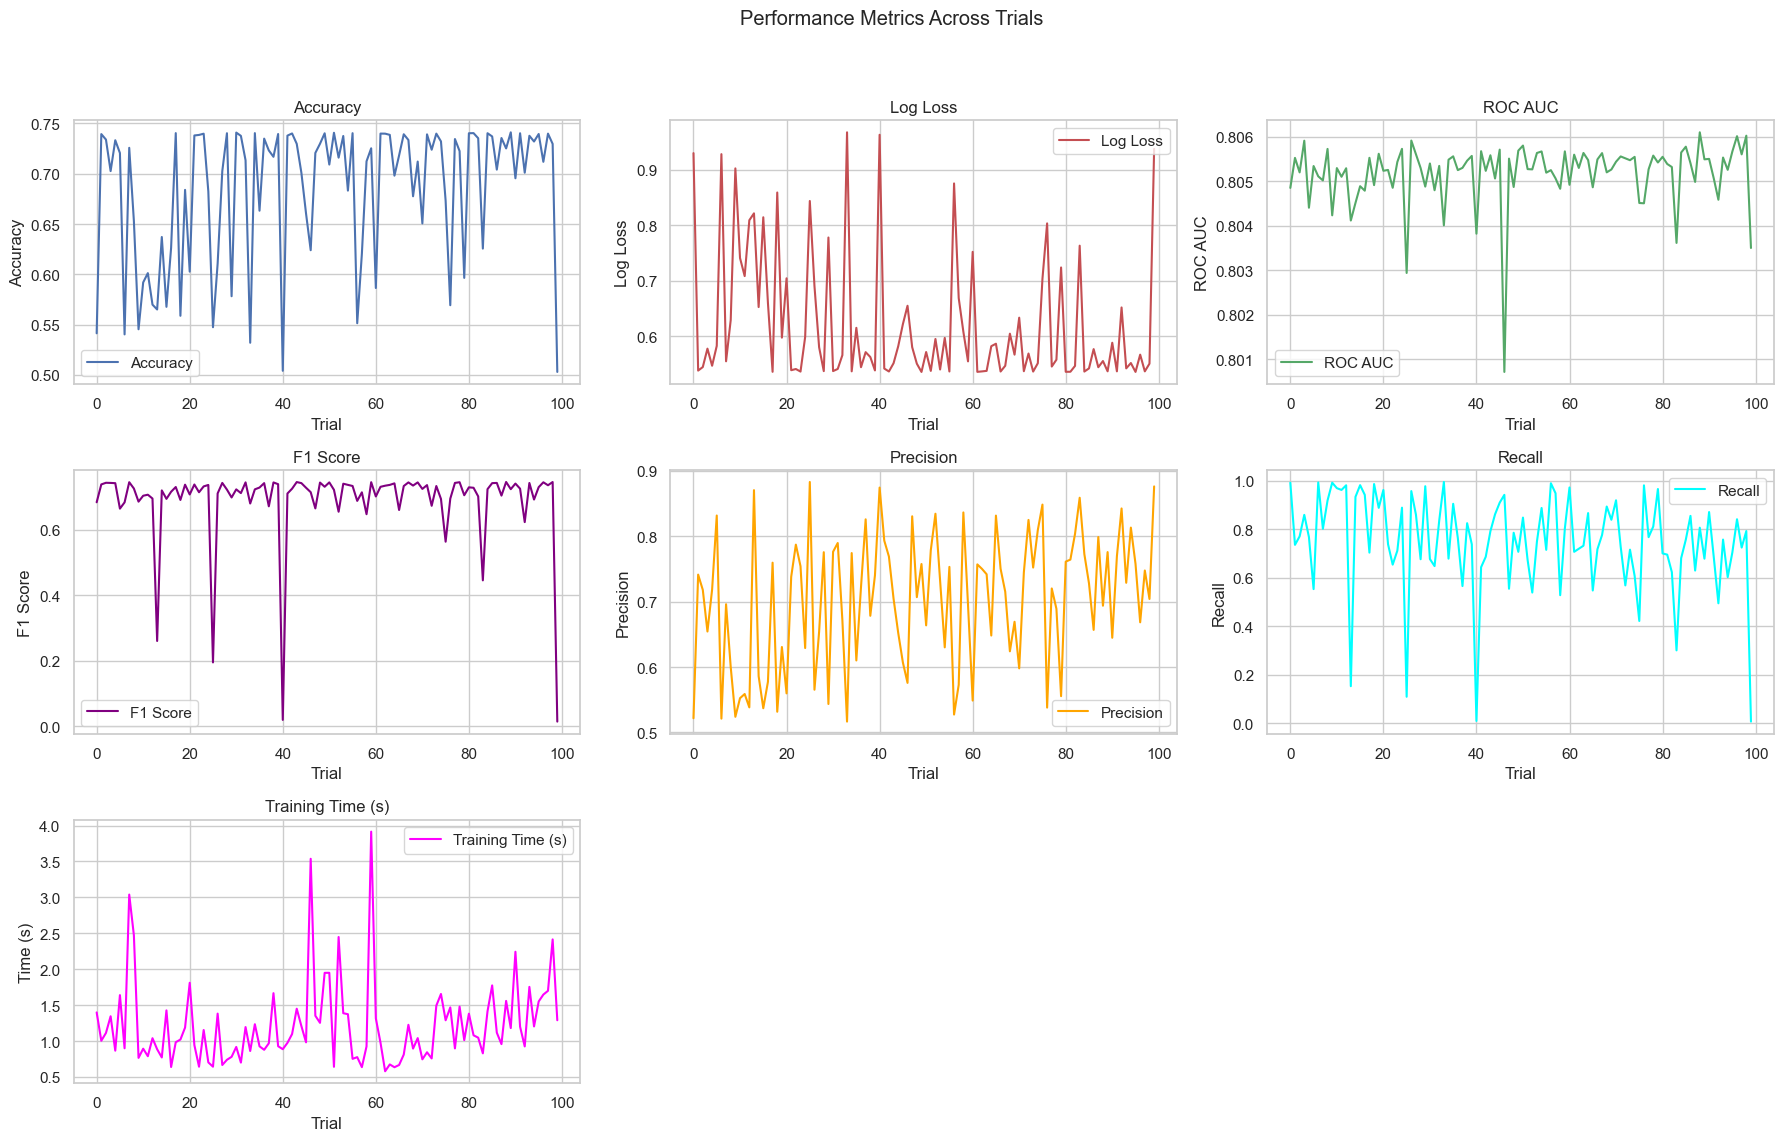

In [42]:
# Извлечение данных из истории триалов
accuracies = [trial.user_attrs['Accuracy'] for trial in study.trials]
log_losses = [trial.values[0] for trial in study.trials]
roc_aucs = [trial.user_attrs['ROC AUC'] for trial in study.trials]
f1_scores = [trial.user_attrs['F1 Score'] for trial in study.trials]
precisions = [trial.user_attrs['Precision'] for trial in study.trials]
recalls = [trial.user_attrs['Recall'] for trial in study.trials]
training_times = [trial.user_attrs['Training Time (s)'] for trial in study.trials]

# Построение графиков
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
fig.suptitle('Performance Metrics Across Trials')

# Accuracy
axes[0, 0].plot(accuracies, label='Accuracy', color='b')
axes[0, 0].set_title('Accuracy')
axes[0, 0].set_xlabel('Trial')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()

# Log Loss
axes[0, 1].plot(log_losses, label='Log Loss', color='r')
axes[0, 1].set_title('Log Loss')
axes[0, 1].set_xlabel('Trial')
axes[0, 1].set_ylabel('Log Loss')
axes[0, 1].legend()

# ROC AUC
axes[0, 2].plot(roc_aucs, label='ROC AUC', color='g')
axes[0, 2].set_title('ROC AUC')
axes[0, 2].set_xlabel('Trial')
axes[0, 2].set_ylabel('ROC AUC')
axes[0, 2].legend()

# F1 Score
axes[1, 0].plot(f1_scores, label='F1 Score', color='purple')
axes[1, 0].set_title('F1 Score')
axes[1, 0].set_xlabel('Trial')
axes[1, 0].set_ylabel('F1 Score')
axes[1, 0].legend()

# Precision
axes[1, 1].plot(precisions, label='Precision', color='orange')
axes[1, 1].set_title('Precision')
axes[1, 1].set_xlabel('Trial')
axes[1, 1].set_ylabel('Precision')
axes[1, 1].legend()

# Recall
axes[1, 2].plot(recalls, label='Recall', color='cyan')
axes[1, 2].set_title('Recall')
axes[1, 2].set_xlabel('Trial')
axes[1, 2].set_ylabel('Recall')
axes[1, 2].legend()

# Training Time
axes[2, 0].plot(training_times, label='Training Time (s)', color='magenta')
axes[2, 0].set_title('Training Time (s)')
axes[2, 0].set_xlabel('Trial')
axes[2, 0].set_ylabel('Time (s)')
axes[2, 0].legend()

# Очистка неиспользуемых субплотов
axes[2, 1].axis('off')
axes[2, 2].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


# catboost_learn

0:	learn: 0.6676442	test: 0.6674970	best: 0.6674970 (0)	total: 15.9ms	remaining: 5.86s
50:	learn: 0.5376405	test: 0.5375983	best: 0.5375983 (50)	total: 523ms	remaining: 3.26s
100:	learn: 0.5333830	test: 0.5358571	best: 0.5358485 (98)	total: 1.02s	remaining: 2.7s
150:	learn: 0.5305395	test: 0.5354960	best: 0.5354764 (140)	total: 1.53s	remaining: 2.21s
bestTest = 0.5354764384
bestIteration = 140
Shrink model to first 141 iterations.


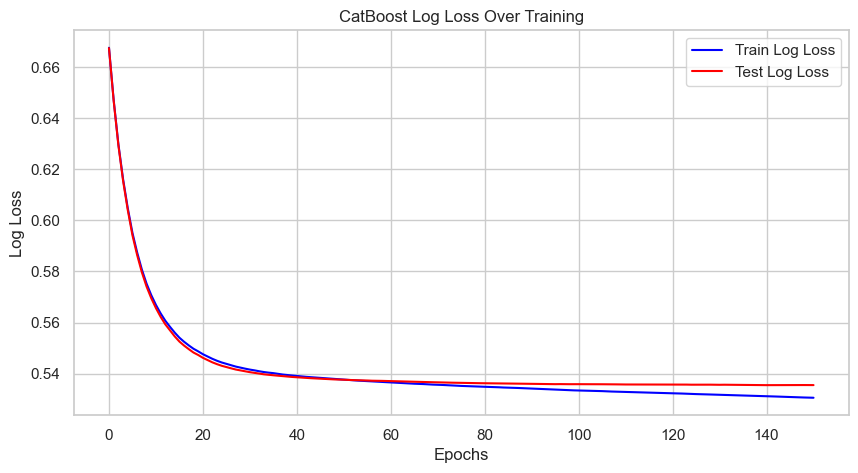

In [43]:
# Предполагаем, что df_train уже загружен и содержит необходимые данные
X = df_train.drop('cardio', axis=1)
y = df_train['cardio']

# Разделение данных на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Параметры модели CatBoost
params = {
    'iterations': 369,
    'learning_rate': 0.08626498613685497,
    'depth': 5,
    'loss_function': 'Logloss',
    'verbose': 50,
    'task_type': 'GPU',  # Если у вас доступна поддержка GPU
    'early_stopping_rounds': 10,
    'random_state':0,
    'random_strength': 1,
    'bagging_temperature': 0.0010295041344297456,
    'border_count': 158,
    'l2_leaf_reg': 1.8083436683000222,
    'scale_pos_weight': 0.9786437563189619
}

# Создание и обучение модели
model = cb.CatBoostClassifier(**params)
model.fit(X_train, y_train, eval_set=(X_test, y_test), plot=False)

# Получение log loss для тренировочных и тестовых данных
evals_result = model.get_evals_result()
train_logloss = evals_result['learn']['Logloss']
test_logloss = evals_result['validation']['Logloss']
epochs = len(train_logloss)
x_axis = range(0, epochs)

# Создание графика
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x_axis, train_logloss, label='Train Log Loss', color='blue')
ax.plot(x_axis, test_logloss, label='Test Log Loss', color='red')
ax.legend()

plt.ylabel('Log Loss')
plt.xlabel('Epochs')
plt.title('CatBoost Log Loss Over Training')
plt.show()


In [44]:
# Категориальные и числовые столбцы
categorical_columns = ['cholesterol', 'gluc', 'gender', 'smoke', 'alco', 'active']
numerical_columns = ['age', 'height', 'weight', 'ap_hi', 'ap_lo', 'bmi', 'avrg_ap', 'aphi_chol_gluc', 'ssz_risc']

# Разделение данных на признаки и целевую переменную
X = df_train.drop('cardio', axis=1)
y = df_train['cardio']

# Разделение на обучающий и тестовый набор данных
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Подготовка трансформеров для категориальных и числовых столбцов
ct = make_column_transformer(
    (OneHotEncoder(), categorical_columns),
    remainder='passthrough'
)

# Список моделей
models = [
    ('XGBoost', XGBClassifier(random_state=0, tree_method='hist')),
    ('LightGBM', LGBMClassifier(random_state=0, device='cpu')),
    ('CatBoost', CatBoostClassifier(random_state=0, task_type='CPU')),
]

# Словарь для сохранения результатов
results = {}

# Итерация по моделям
for name, model in models:
    pipe = make_pipeline(ct, model)
    start_time = time.time()
    pipe.fit(X_train, y_train)
    training_time = time.time() - start_time
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]  # Вероятности для ROC AUC

    # Расчет метрик
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Log Loss': log_loss(y_test, y_proba),
        'ROC AUC': roc_auc_score(y_test, y_proba),
        'F1 Score': f1_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'Training Time (s)': training_time
    }

# Создание DataFrame из результатов
results_df = pd.DataFrame(results)

# Функции для подсветки максимальных и минимальных значений
def highlight_max(data, color='green'):
    attr = f'background-color: {color}; color: white'
    if data.name == 'Training Time (s)' or data.name == 'Log Loss':
        is_max = data == data.min()
    else:
        is_max = data == data.max()
    return [attr if v else '' for v in is_max]

def highlight_min(data, color='red'):
    attr = f'background-color: {color}; color: white'
    if data.name == 'Training Time (s)' or data.name == 'Log Loss':
        is_min = data == data.max()
    else:
        is_min = data == data.min()
    return [attr if v else '' for v in is_min]

# Применение стилизации к DataFrame
styled_df = results_df.style.apply(highlight_max, axis=1).apply(highlight_min, axis=1)

# Вывод стилизованного DataFrame
styled_df


Learning rate set to 0.063211
0:	learn: 0.6744064	total: 10.3ms	remaining: 10.3s
1:	learn: 0.6582009	total: 19.4ms	remaining: 9.67s
2:	learn: 0.6438668	total: 30ms	remaining: 9.99s
3:	learn: 0.6314551	total: 40.3ms	remaining: 10s
4:	learn: 0.6209533	total: 52.2ms	remaining: 10.4s
5:	learn: 0.6120370	total: 64.5ms	remaining: 10.7s
6:	learn: 0.6037694	total: 74.3ms	remaining: 10.5s
7:	learn: 0.5966436	total: 85ms	remaining: 10.5s
8:	learn: 0.5907838	total: 94.8ms	remaining: 10.4s
9:	learn: 0.5850684	total: 105ms	remaining: 10.4s
10:	learn: 0.5800632	total: 115ms	remaining: 10.3s
11:	learn: 0.5758952	total: 125ms	remaining: 10.3s
12:	learn: 0.5720309	total: 136ms	remaining: 10.3s
13:	learn: 0.5689858	total: 146ms	remaining: 10.3s
14:	learn: 0.5661422	total: 156ms	remaining: 10.2s
15:	learn: 0.5634117	total: 167ms	remaining: 10.3s
16:	learn: 0.5612506	total: 179ms	remaining: 10.3s
17:	learn: 0.5591404	total: 191ms	remaining: 10.4s
18:	learn: 0.5572726	total: 202ms	remaining: 10.4s
19:	lear

,XGBoost,LightGBM,CatBoost
Accuracy,0.737400,0.739467,0.740467
Log Loss,0.543415,0.536268,0.538105
ROC AUC,0.800928,0.805246,0.804423
F1 Score,0.726951,0.728441,0.729596
Precision,0.757129,0.760685,0.761546
Recall,0.699087,0.698820,0.700220
Training Time (s),0.289732,0.248179,10.993920


In [45]:
# Категориальные и числовые столбцы
categorical_columns = ['cholesterol', 'gluc', 'gender', 'smoke', 'alco', 'active']
numerical_columns = ['age', 'height', 'weight', 'ap_hi', 'ap_lo', 'bmi', 'avrg_ap', 'aphi_chol_gluc', 'ssz_risc']

# Разделение данных на признаки и целевую переменную
X = df_train.drop('cardio', axis=1)
y = df_train['cardio']

# Разделение на обучающий и тестовый набор данных
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Подготовка трансформеров для категориальных и числовых столбцов
ct = make_column_transformer(
    (OneHotEncoder(), categorical_columns),
    remainder='passthrough'
)

# Список моделей
models = [
    ('XGBoost', XGBClassifier(random_state=0, tree_method='hist')),
    ('LightGBM', LGBMClassifier(random_state=0, device='gpu')),
    ('CatBoost', CatBoostClassifier(random_state=0, task_type='GPU')),
]

# Словарь для сохранения результатов
results = {}

# Итерация по моделям
for name, model in models:
    pipe = make_pipeline(ct, model)
    start_time = time.time()
    pipe.fit(X_train, y_train)
    training_time = time.time() - start_time
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]  # Вероятности для ROC AUC

    # Расчет метрик
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Log Loss': log_loss(y_test, y_proba),
        'ROC AUC': roc_auc_score(y_test, y_proba),
        'F1 Score': f1_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'Training Time (s)': training_time
    }

# Создание DataFrame из результатов
results_df = pd.DataFrame(results)

# Функции для подсветки максимальных и минимальных значений
def highlight_max(data, color='green'):
    attr = f'background-color: {color}; color: white'
    if data.name == 'Training Time (s)' or data.name == 'Log Loss':
        is_max = data == data.min()
    else:
        is_max = data == data.max()
    return [attr if v else '' for v in is_max]

def highlight_min(data, color='red'):
    attr = f'background-color: {color}; color: white'
    if data.name == 'Training Time (s)' or data.name == 'Log Loss':
        is_min = data == data.max()
    else:
        is_min = data == data.min()
    return [attr if v else '' for v in is_min]

# Применение стилизации к DataFrame
styled_df = results_df.style.apply(highlight_max, axis=1).apply(highlight_min, axis=1)

# Вывод стилизованного DataFrame
styled_df


Learning rate set to 0.026687
0:	learn: 0.6850671	total: 9.15ms	remaining: 9.14s
1:	learn: 0.6772786	total: 17.4ms	remaining: 8.67s
2:	learn: 0.6700084	total: 25.5ms	remaining: 8.46s
3:	learn: 0.6630435	total: 33.7ms	remaining: 8.38s
4:	learn: 0.6564253	total: 42.4ms	remaining: 8.43s
5:	learn: 0.6502560	total: 50.9ms	remaining: 8.43s
6:	learn: 0.6444226	total: 58.5ms	remaining: 8.3s
7:	learn: 0.6390336	total: 66.8ms	remaining: 8.29s
8:	learn: 0.6338724	total: 75.5ms	remaining: 8.31s
9:	learn: 0.6290488	total: 84.6ms	remaining: 8.37s
10:	learn: 0.6244344	total: 93ms	remaining: 8.37s
11:	learn: 0.6201112	total: 102ms	remaining: 8.38s
12:	learn: 0.6161225	total: 111ms	remaining: 8.39s
13:	learn: 0.6122130	total: 122ms	remaining: 8.57s
14:	learn: 0.6084841	total: 130ms	remaining: 8.56s
15:	learn: 0.6049987	total: 139ms	remaining: 8.54s
16:	learn: 0.6019318	total: 147ms	remaining: 8.53s
17:	learn: 0.5988460	total: 156ms	remaining: 8.51s
18:	learn: 0.5959451	total: 164ms	remaining: 8.49s
19:

,XGBoost,LightGBM,CatBoost
Accuracy,0.737400,0.739467,0.741100
Log Loss,0.543415,0.536268,0.535990
ROC AUC,0.800928,0.805243,0.805698
F1 Score,0.726951,0.728441,0.730078
Precision,0.757129,0.760685,0.762596
Recall,0.699087,0.698820,0.700220
Training Time (s),0.299064,1.230742,10.591677


In [46]:
# Категориальные и числовые столбцы
categorical_columns = ['cholesterol', 'gluc', 'gender', 'smoke', 'alco', 'active']
numerical_columns = ['age', 'height', 'weight', 'ap_hi', 'ap_lo', 'bmi', 'avrg_ap', 'aphi_chol_gluc', 'ssz_risc']

# Разделение данных на признаки и целевую переменную
X = df_train.drop('cardio', axis=1)
y = df_train['cardio']

# Разделение на обучающий и тестовый набор данных
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Подготовка трансформеров для категориальных и числовых столбцов
ct = make_column_transformer(
    (OneHotEncoder(), categorical_columns),
    remainder='passthrough'
)

# Список моделей
models = [
    ('XGBoost', XGBClassifier(random_state=0, n_estimators=784, max_depth=5,learning_rate=0.03763684704283537, 
                              colsample_bytree=0.5737561467653175, subsample=0.9256409353682482, min_child_weight=106,
                              tree_method='hist')),
    ('LightGBM', LGBMClassifier(random_state=0, learning_rate=0.023124521753140295, n_estimators=929, num_leaves=31,
    min_child_samples=70, feature_fraction=0.49233144168351883, bagging_fraction=0.9159371930878285, bagging_freq=1,
    lambda_l1=1.3213887596871343, lambda_l2=8.585146879940105e-05, device='cpu')),
    ('CatBoost', CatBoostClassifier(iterations=369, learning_rate=0.08626498613685497, depth=5,
    early_stopping_rounds=10, random_state=0, random_strength=1, bagging_temperature=0.0010295041344297456,
    border_count=158, l2_leaf_reg=1.8083436683000222, scale_pos_weight=0.9786437563189619, verbose=0, task_type='CPU')),
]

# Словарь для сохранения результатов
results = {}

# Итерация по моделям
for name, model in models:
    pipe = make_pipeline(ct, model)
    start_time = time.time()
    pipe.fit(X_train, y_train)
    training_time = time.time() - start_time
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]  # Вероятности для ROC AUC

    # Расчет метрик
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Log Loss': log_loss(y_test, y_proba),
        'ROC AUC': roc_auc_score(y_test, y_proba),
        'F1 Score': f1_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'Training Time (s)': training_time
    }

# Создание DataFrame из результатов
results_df = pd.DataFrame(results)

# Функции для подсветки максимальных и минимальных значений
def highlight_max(data, color='green'):
    attr = f'background-color: {color}; color: white'
    if data.name == 'Training Time (s)' or data.name == 'Log Loss':
        is_max = data == data.min()
    else:
        is_max = data == data.max()
    return [attr if v else '' for v in is_max]

def highlight_min(data, color='red'):
    attr = f'background-color: {color}; color: white'
    if data.name == 'Training Time (s)' or data.name == 'Log Loss':
        is_min = data == data.max()
    else:
        is_min = data == data.min()
    return [attr if v else '' for v in is_min]

# Применение стилизации к DataFrame
styled_df = results_df.style.apply(highlight_max, axis=1).apply(highlight_min, axis=1)

# Вывод стилизованного DataFrame
styled_df


,XGBoost,LightGBM,CatBoost
Accuracy,0.740033,0.740600,0.740500
Log Loss,0.536071,0.536404,0.536270
ROC AUC,0.805550,0.805389,0.805535
F1 Score,0.729436,0.729829,0.727349
Precision,0.760489,0.761501,0.766234
Recall,0.700820,0.700687,0.692221
Training Time (s),2.370907,2.155496,4.084245


In [47]:
# Категориальные и числовые столбцы
categorical_columns = ['cholesterol', 'gluc', 'gender', 'smoke', 'alco', 'active']
numerical_columns = ['age', 'height', 'weight', 'ap_hi', 'ap_lo', 'bmi', 'avrg_ap', 'aphi_chol_gluc', 'ssz_risc']

# Разделение данных на признаки и целевую переменную
X = df_train.drop('cardio', axis=1)
y = df_train['cardio']

# Разделение на обучающий и тестовый набор данных
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Подготовка трансформеров для категориальных и числовых столбцов
ct = make_column_transformer(
    (OneHotEncoder(), categorical_columns),
    remainder='passthrough'
)

# Список моделей
models = [
    ('XGBoost', XGBClassifier(random_state=42, n_estimators=784, max_depth=5,learning_rate=0.03763684704283537, 
                              colsample_bytree=0.5737561467653175, subsample=0.9256409353682482, min_child_weight=106,
                              tree_method='hist')),
    ('LightGBM', LGBMClassifier(random_state=42, learning_rate=0.023124521753140295, n_estimators=629, num_leaves=31,
    min_child_samples=70, feature_fraction=0.49233144168351883, bagging_fraction=0.9159371930878285, bagging_freq=1,
    lambda_l1=1.3213887596871343, lambda_l2=8.585146879940105e-05, device='gpu')),
    ('CatBoost', CatBoostClassifier(iterations=369, learning_rate=0.08626498613685497, depth=5,
    early_stopping_rounds=10, random_state=42, random_strength=1, bagging_temperature=0.0010295041344297456,
    border_count=158, l2_leaf_reg=1.8083436683000222, scale_pos_weight=0.9786437563189619, verbose=0, task_type='GPU'))
]

# Словарь для сохранения результатов
results = {}

# Итерация по моделям
for name, model in models:
    pipe = make_pipeline(ct, model)
    start_time = time.time()
    pipe.fit(X_train, y_train)
    training_time = time.time() - start_time
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]  # Вероятности для ROC AUC

    # Расчет метрик
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Log Loss': log_loss(y_test, y_proba),
        'ROC AUC': roc_auc_score(y_test, y_proba),
        'F1 Score': f1_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'Training Time (s)': training_time
    }

# Создание DataFrame из результатов
results_df = pd.DataFrame(results)

# Функции для подсветки максимальных и минимальных значений
def highlight_max(data, color='green'):
    attr = f'background-color: {color}; color: white'
    if data.name == 'Training Time (s)' or data.name == 'Log Loss':
        is_max = data == data.min()
    else:
        is_max = data == data.max()
    return [attr if v else '' for v in is_max]

def highlight_min(data, color='red'):
    attr = f'background-color: {color}; color: white'
    if data.name == 'Training Time (s)' or data.name == 'Log Loss':
        is_min = data == data.max()
    else:
        is_min = data == data.min()
    return [attr if v else '' for v in is_min]

# Применение стилизации к DataFrame
styled_df = results_df.style.apply(highlight_max, axis=1).apply(highlight_min, axis=1)

# Вывод стилизованного DataFrame
styled_df

,XGBoost,LightGBM,CatBoost
Accuracy,0.739800,0.739433,0.740467
Log Loss,0.536057,0.535587,0.536153
ROC AUC,0.805502,0.805992,0.805666
F1 Score,0.728996,0.728605,0.727781
Precision,0.760632,0.760252,0.765238
Recall,0.699887,0.699487,0.693820
Training Time (s),2.307843,6.908835,3.847322


In [49]:
# Предположим, что df_train - это DataFrame с данными
X = df_train.drop('cardio', axis=1)
y = df_train['cardio']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Определение столбцов
categorical_columns = ['cholesterol', 'gluc', 'gender', 'smoke', 'alco', 'active']
numeric_columns = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']

# Создание и обучение StandardScaler
scaler = StandardScaler()
X_train_numeric_scaled = scaler.fit_transform(X_train[numeric_columns])
X_test_numeric_scaled = scaler.transform(X_test[numeric_columns])

# Сохранение StandardScaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Обучение GradientBoostingClassifier после применения OneHotEncoder для категориальных данных
categorical_transformer = OneHotEncoder()
X_train_categorical_encoded = categorical_transformer.fit_transform(X_train[categorical_columns])
X_test_categorical_encoded = categorical_transformer.transform(X_test[categorical_columns])

# Объединение обработанных числовых и категориальных данных
import scipy.sparse
X_train_prepared = scipy.sparse.hstack((X_train_numeric_scaled, X_train_categorical_encoded))
X_test_prepared = scipy.sparse.hstack((X_test_numeric_scaled, X_test_categorical_encoded))

# Создание и обучение модели
model = XGBClassifier(random_state=0, n_estimators=784, max_depth=5,learning_rate=0.03763684704283537, 
                              colsample_bytree=0.5737561467653175, subsample=0.9256409353682482, min_child_weight=106,
                              tree_method='hist')
model.fit(X_train_prepared, y_train)

# Сохранение модели
with open('model.pkl', 'wb') as f:
    pickle.dump(model, f)